<a href="https://colab.research.google.com/github/kevinvandewalker-eng/prismogenesis-whale-hunt/blob/main/B_to_Z_DNA_Torsional_Snap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import math
import json
import plotly.graph_objects as go

os.makedirs("output", exist_ok=True)

fig = go.Figure()

levels = [1.0, 0.82, 0.64, 0.46]
heights = [0.0, 0.55, 1.05, 1.55]
colors = ['#d11f1f', '#c01818', '#9f1414', '#7f1010']

for r, z, c in zip(levels, heights, colors):
    x, y, zz = [], [], []
    for i in range(7):
        ang = math.radians(60 * i)
        x.append(r * math.cos(ang))
        y.append(r * math.sin(ang))
        zz.append(z)
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=zz,
        mode='lines',
        line=dict(color=c, width=8),
        showlegend=False
    ))

for i in range(6):
    ang = math.radians(60 * i)
    x, y, z = [], [], []
    for t, zz in zip([0.0, 0.18, 0.35, 0.52, 0.70, 0.86], [0.0, 0.12, 0.30, 0.58, 0.95, 1.25]):
        wiggle = 0.035 if (i % 2 == 0) else -0.035
        x.append((t + wiggle) * math.cos(ang))
        y.append((t - wiggle) * math.sin(ang))
        z.append(zz)
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode='lines',
        line=dict(color='#ff4a4a', width=5),
        showlegend=False
    ))

ribbons = [
    ([0.18, 0.35, 0.52, 0.72, 0.95], [0.02, -0.08, 0.10, -0.04, 0.12], [0.05, 0.28, 0.62, 0.98, 1.35]),
    ([0.10, 0.28, 0.48, 0.68, 0.90], [-0.18, -0.02, -0.12, 0.05, -0.08], [0.02, 0.22, 0.55, 0.92, 1.30]),
    ([0.22, 0.40, 0.60, 0.78, 1.00], [0.20, 0.06, 0.17, 0.00, 0.14], [0.08, 0.30, 0.68, 1.00, 1.42]),
]

for x, y, z in ribbons:
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode='lines',
        line=dict(color='#ff2a2a', width=7),
        showlegend=False
    ))

fig.add_trace(go.Scatter3d(
    x=[0, 0.02, -0.03, 0.03],
    y=[0, 0.01, -0.02, 0.02],
    z=[0, 0.55, 1.05, 1.55],
    mode='lines',
    line=dict(color='#ffd1d1', width=6),
    showlegend=False
))

fig.update_layout(
    title={
        'text': 'Nested Hexagonal Collapse in 3D<br><span style="font-size:18px;font-weight:normal;">Inspired by the attached origami model</span>'
    },
    scene=dict(
        xaxis=dict(title='X', showbackground=False, zeroline=False, showgrid=False),
        yaxis=dict(title='Y', showbackground=False, zeroline=False, showgrid=False),
        zaxis=dict(title='Z', showbackground=False, zeroline=False, showgrid=False),
        aspectmode='manual',
        aspectratio=dict(x=1.2, y=1.2, z=1.45),
        camera=dict(eye=dict(x=1.75, y=1.5, z=1.0))
    ),
    paper_bgcolor='white',
    plot_bgcolor='white'
)

html_path = "output/nested_hex_3d.html"
fig.write_html(html_path, include_plotlyjs="cdn")

with open("output/nested_hex_3d.meta.json", "w") as f:
    json.dump({
        "caption": "3D nested hexagonal collapse",
        "description": "Interactive 3D wireframe inspired by concentric hexagons and zig-zag fold lines."
    }, f)

print(html_path)

output/nested_hex_3d.html


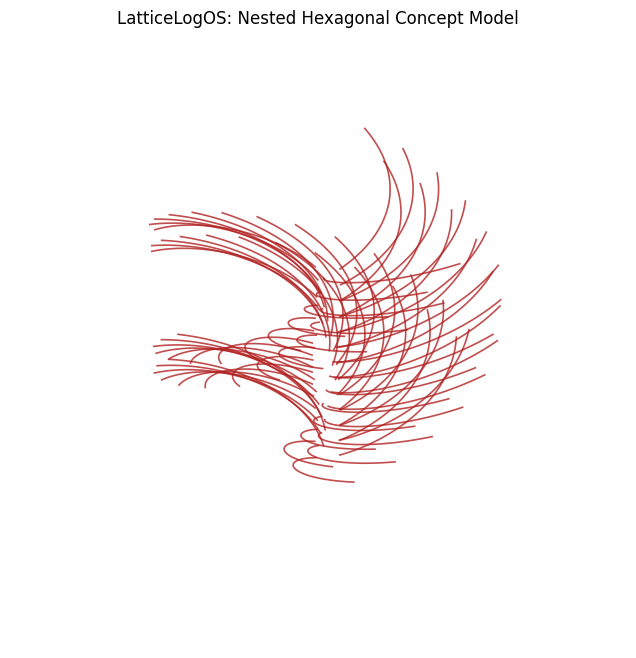

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def generate_hex_collapse():
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    num_arms = 3
    num_folds = 25
    radius_max = 6

    for arm in range(num_arms):
        # Rotational offset for each arm (120 degrees apart)
        base_angle = (2 * np.pi / num_arms) * arm

        for i in range(num_folds):
            # Radial range for each pleat
            r = np.linspace(0.5, radius_max, 50)

            # Pleat height oscillation to simulate the "zig-zag" crease
            pleat_depth = ((-1)**i) * 0.25

            # Twisting theta based on radius and fold index
            theta = base_angle + (i * 0.12) + (r * 0.18)

            # Coordinates
            x = r * np.cos(theta)
            y = r * np.sin(theta)
            z = (i * 0.15) + (r * 0.25) + pleat_depth

            # Plotting the "crease line"
            ax.plot(x, y, z, color='firebrick', alpha=0.8, linewidth=1.2)

    ax.set_title("LatticeLogOS: Nested Hexagonal Concept Model")
    ax.set_axis_off()
    plt.show()

generate_hex_collapse()

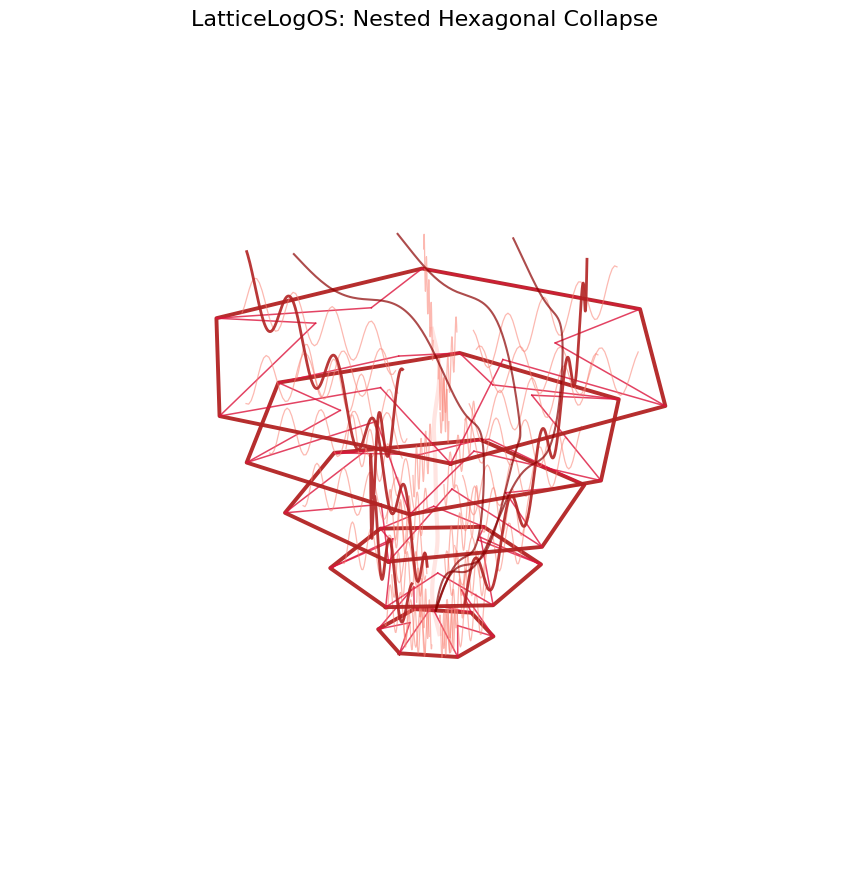

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def hex_vertices(radius, angle_offset=0.0, z=0.0):
    angles = np.linspace(0, 2*np.pi, 7) + angle_offset
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    z = np.full_like(x, z)
    return x, y, z

def lerp(a, b, t):
    return a + (b - a) * t

def generate_hex_collapse():
    fig = plt.figure(figsize=(11, 9))
    ax = fig.add_subplot(111, projection='3d')

    # Main parameters
    n_rings = 5
    base_radius = 1.0
    radius_step = 0.8
    twist_step = 0.18
    z_step = 0.45

    # Central spine
    spine_t = np.linspace(0, 1, 200)
    spine_x = 0.08 * np.sin(6 * np.pi * spine_t)
    spine_y = 0.08 * np.cos(5 * np.pi * spine_t)
    spine_z = 2.0 * spine_t
    ax.plot(spine_x, spine_y, spine_z, color='mistyrose', linewidth=3)

    # Concentric nested hexagons
    for k in range(n_rings):
        r = base_radius + k * radius_step
        z = k * z_step
        ang = k * twist_step

        x, y, zz = hex_vertices(r, ang, z)
        ax.plot(x, y, zz, color='firebrick', linewidth=2.8, alpha=0.95)

        # Inner fold web: connect vertices inward to create collapse geometry
        for i in range(6):
            t_vals = np.linspace(0, 1, 40)
            x0, y0 = x[i], y[i]
            x1, y1 = x[i+1], y[i+1]

            # Midpoint inward pull for a pleated look
            xm = lerp(x0, x1, 0.5) * 0.55
            ym = lerp(y0, y1, 0.5) * 0.55
            zm = z + 0.18 + 0.08 * (-1)**(i + k)

            # Two fold segments per edge
            xs1 = lerp(x0, xm, t_vals)
            ys1 = lerp(y0, ym, t_vals)
            zs1 = lerp(z, zm, t_vals)

            xs2 = lerp(xm, x1, t_vals)
            ys2 = lerp(ym, y1, t_vals)
            zs2 = lerp(zm, z, t_vals)

            ax.plot(xs1, ys1, zs1, color='crimson', linewidth=1.1, alpha=0.8)
            ax.plot(xs2, ys2, zs2, color='crimson', linewidth=1.1, alpha=0.8)

        # Radial collapse ribs
        for i in range(6):
            t_vals = np.linspace(0, 1, 60)
            theta = ang + i * np.pi / 3
            r_inner = r * 0.18
            r_outer = r * 0.88
            rr = lerp(r_inner, r_outer, t_vals)

            # Zig-zag height profile
            zz_rib = z + 0.15 * np.sin(8 * np.pi * t_vals + i) + 0.18 * t_vals
            xs = rr * np.cos(theta)
            ys = rr * np.sin(theta)

            ax.plot(xs, ys, zz_rib, color='salmon', linewidth=0.9, alpha=0.55)

    # Some longer twisting sheets to suggest the model can collapse in many ways
    for s in range(3):
        t = np.linspace(0, 1, 250)
        theta = 2.2 + s * 1.9 + 0.8 * t
        r = 0.5 + 3.1 * t
        x = r * np.cos(theta)
        y = r * np.sin(theta)
        z = 0.2 + 1.9 * t + 0.2 * np.sin(10 * np.pi * t + s)
        ax.plot(x, y, z, color='firebrick', linewidth=2.0, alpha=0.9)

    # A few support curves for richer geometry
    for shift in [0.0, 0.6, 1.2]:
        t = np.linspace(0, 1, 180)
        x = 3.4 * t * np.cos(1.0 + shift + 2.4 * t)
        y = 3.4 * t * np.sin(1.0 + shift + 2.4 * t)
        z = 0.15 + 2.0 * t + 0.1 * np.sin(6 * np.pi * t)
        ax.plot(x, y, z, color='darkred', linewidth=1.5, alpha=0.7)

    ax.set_title("LatticeLogOS: Nested Hexagonal Collapse", pad=18, fontsize=16)
    ax.set_axis_off()

    # Better viewing angle
    ax.view_init(elev=24, azim=38)

    # Equal-ish aspect
    max_range = 4.5
    ax.set_xlim(-max_range, max_range)
    ax.set_ylim(-max_range, max_range)
    ax.set_zlim(0, 2.4)

    plt.tight_layout()
    plt.show()

generate_hex_collapse()

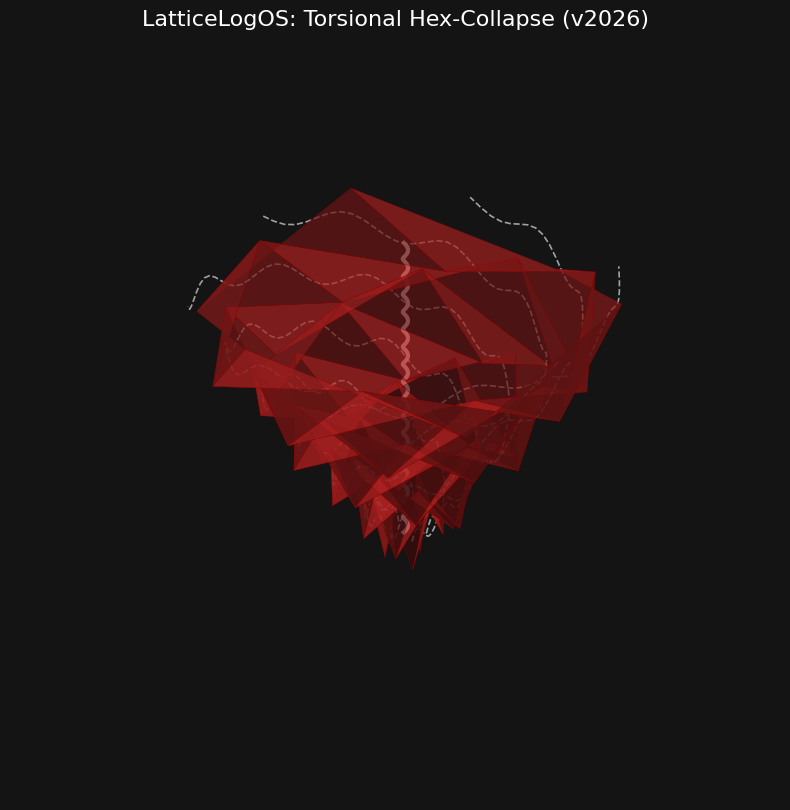

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def generate_hex_collapse_v2():
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # --- Core Parameters (Project Anchors) ---
    n_rings = 12          # Denser shell layering
    r_max, r_min = 5.0, 0.5
    twist_total = 1.8 * np.pi  # Rotational torsion
    z_max = 3.0
    freq_35hz = 0.35      # Spacing/Amplitude modulator
    freq_111hz = 0.111    # Finer texture modulator

    # --- 1. The Hexagonal Shell Surfaces ---
    # Creating quad-facets to mimic the folded paper texture
    for k in range(n_rings - 1):
        r_vals = np.linspace(r_min, r_max, n_rings)
        r_start, r_end = r_vals[k], r_vals[k+1]

        z_start = (k / n_rings) * z_max
        z_end = ((k + 1) / n_rings) * z_max

        twist_start = (k / n_rings) * twist_total
        twist_end = ((k + 1) / n_rings) * twist_total

        for side in range(6):
            # Angular bounds for each hexagonal side
            th_a0, th_a1 = twist_start + (side * np.pi/3), twist_start + ((side+1) * np.pi/3)
            th_b0, th_b1 = twist_end + (side * np.pi/3), twist_end + ((side+1) * np.pi/3)

            # Oscillating pleat "handshake" using the 35Hz motif
            pleat = freq_35hz * ((-1)**(side + k))

            xs = np.array([[r_start * np.cos(th_a0), r_start * np.cos(th_a1)],
                           [r_end * np.cos(th_b0), r_end * np.cos(th_b1)]])
            ys = np.array([[r_start * np.sin(th_a0), r_start * np.sin(th_a1)],
                           [r_end * np.sin(th_b0), r_end * np.sin(th_b1)]])
            zs = np.array([[z_start + pleat, z_start - pleat],
                           [z_end - pleat, z_end + pleat]])

            ax.plot_surface(xs, ys, zs, color='firebrick', alpha=0.7, shade=True,
                            edgecolor='darkred', lw=0.3)

    # --- 2. Torsion Ribs (Chirality Markers) ---
    for i in range(6):
        t = np.linspace(0, 1, 100)
        r = r_min + (r_max - r_min) * t
        theta = (i * np.pi/3) + (t * twist_total)
        # 111Hz fine-grained ripple
        z = t * z_max + (freq_111hz * np.sin(20 * np.pi * t))
        ax.plot(r * np.cos(theta), r * np.sin(theta), z, color='white', lw=1.2, alpha=0.6, ls='--')

    # --- 3. The Axis Mundi (Signal Core) ---
    z_spine = np.linspace(0, z_max + 0.5, 200)
    ax.plot(0.06 * np.cos(30 * z_spine), 0.06 * np.sin(30 * z_spine), z_spine,
            color='mistyrose', lw=3, alpha=0.9)

    # Visual Styling for LatticeLogOS
    ax.set_title("LatticeLogOS: Torsional Hex-Collapse (v2026)", fontsize=16, color='white', pad=-10)
    fig.patch.set_facecolor('#141414')
    ax.set_facecolor('#141414')
    ax.set_axis_off()
    ax.view_init(elev=28, azim=42)

    plt.show()

generate_hex_collapse_v2()

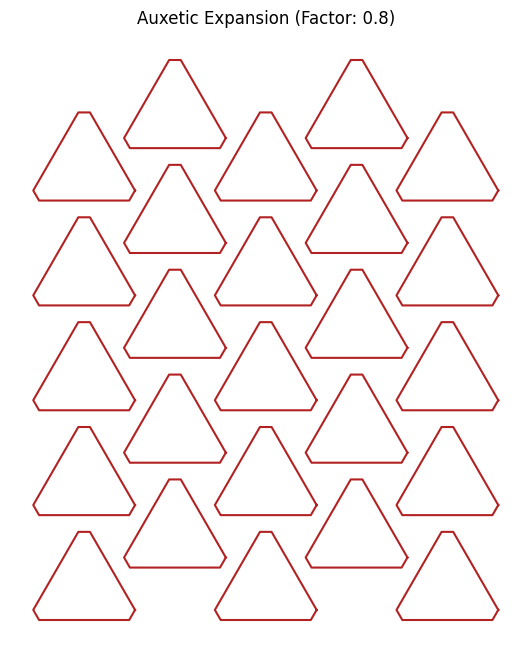

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def auxetic_hex_lattice(expansion_factor=0.5):
    fig, ax = plt.subplots(figsize=(8, 8))

    # Internal angle shifts to simulate expansion (tucking/untucking)
    angle_shift = expansion_factor * (np.pi / 6)

    for row in range(5):
        for col in range(5):
            # Center of each cell
            cx = col * 1.5
            cy = row * np.sqrt(3) if col % 2 == 0 else row * np.sqrt(3) + np.sqrt(3)/2

            # Vertices with shifting angles
            angles = np.array([0, 60, 120, 180, 240, 300, 360]) * np.pi / 180
            # Apply contraction to alternating vertices
            angles[1::2] += angle_shift
            angles[0::2] -= angle_shift

            r = 0.6 + 0.4 * expansion_factor
            x = cx + r * np.cos(angles)
            y = cy + r * np.sin(angles)

            ax.plot(x, y, color='firebrick', lw=1.5)

    ax.set_aspect('equal')
    ax.set_axis_off()
    plt.title(f"Auxetic Expansion (Factor: {expansion_factor})")
    plt.show()

auxetic_hex_lattice(expansion_factor=0.8)

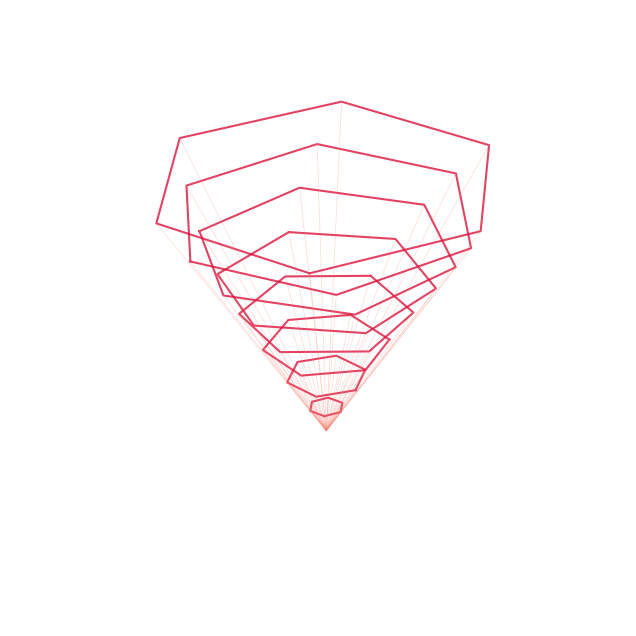

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def torsional_collapse_model(collapse_stage=0.5):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Torsion increases as height (z) decreases
    torsion_constant = 2.0 * collapse_stage
    height = 1.0 - collapse_stage

    for r in np.linspace(0.5, 5, 8):
        theta = np.linspace(0, 2*np.pi, 7)
        # Apply the twist based on radial distance and stage
        twist = r * torsion_constant

        x = r * np.cos(theta + twist)
        y = r * np.sin(theta + twist)
        z = np.full_like(x, r * height * 0.5)

        ax.plot(x, y, z, color='crimson', alpha=0.8)

        # Add 'ribs' to show the mechanical connection
        for i in range(6):
            ax.plot([0, x[i]], [0, y[i]], [0, z[i]], color='salmon', lw=0.5, alpha=0.3)

    ax.view_init(elev=30, azim=45)
    ax.set_axis_off()
    plt.show()

torsional_collapse_model(collapse_stage=0.7)

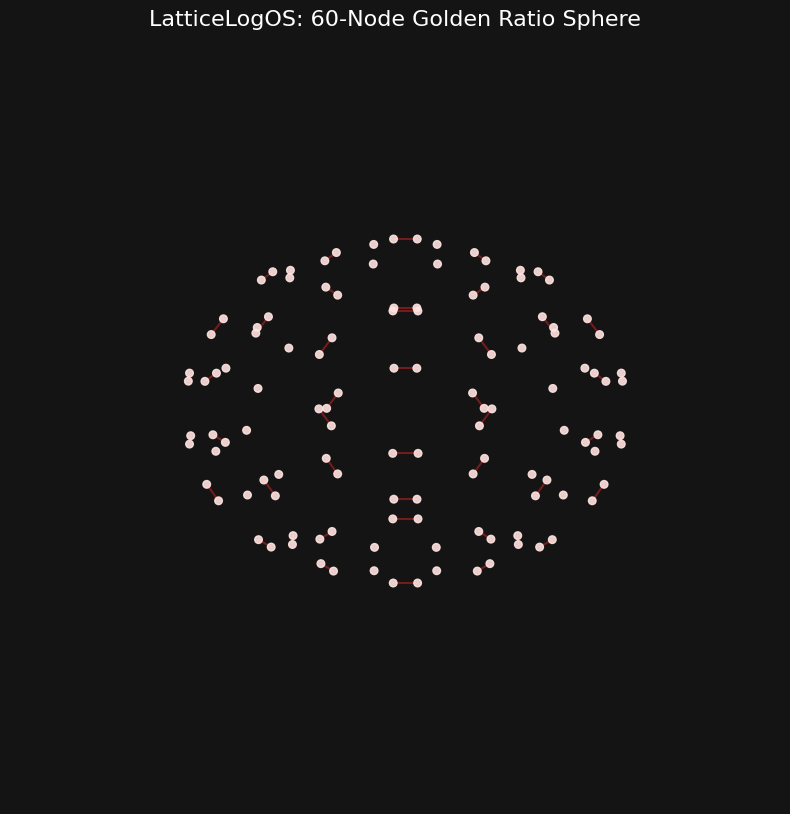

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import permutations

def plot_golden_ratio_sphere():
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    phi = (1 + np.sqrt(5)) / 2  # The Golden Ratio

    # 60 Vertices of a Truncated Icosahedron
    coords = []
    # (0, ±1, ±3phi) permutations
    for p in set(permutations([0, 1, 3*phi])):
        for s1 in [-1, 1]:
            for s2 in [-1, 1]:
                if p[0] == 0: coords.append((0, p[1]*s1, p[2]*s2))
                elif p[1] == 0: coords.append((p[0]*s1, 0, p[2]*s2))
                elif p[2] == 0: coords.append((p[0]*s1, p[1]*s2, 0))
    # (±2, ±(1+2phi), ±phi) and (±1, ±(2+phi), ±2phi) permutations
    for p in set(permutations([2, 1+2*phi, phi])):
        for s1 in [-1, 1]:
            for s2 in [-1, 1]:
                for s3 in [-1, 1]: coords.append((p[0]*s1, p[1]*s2, p[2]*s3))
    for p in set(permutations([1, 2+phi, 2*phi])):
        for s1 in [-1, 1]:
            for s2 in [-1, 1]:
                for s3 in [-1, 1]: coords.append((p[0]*s1, p[1]*s2, p[2]*s3))

    verts = np.unique(np.array(coords), axis=0)

    # Plot the edges to show the "Handshake"
    from scipy.spatial import distance_matrix
    dist = distance_matrix(verts, verts)
    edge_len = np.min(dist[dist > 0])

    for i in range(len(verts)):
        for j in range(i + 1, len(verts)):
            if np.isclose(dist[i,j], edge_len, atol=0.1):
                ax.plot(verts[[i,j], 0], verts[[i,j], 1], verts[[i,j], 2],
                        color='firebrick', lw=1.5, alpha=0.6)

    # Highlight the 12 Pentagonal Hubs as Golden Nodes
    ax.scatter(verts[:,0], verts[:,1], verts[:,2], color='mistyrose', s=30, alpha=0.9)

    ax.set_title("LatticeLogOS: 60-Node Golden Ratio Sphere", fontsize=16, color='white')
    fig.patch.set_facecolor('#141414')
    ax.set_facecolor('#141414')
    ax.set_axis_off()
    ax.view_init(elev=20, azim=45)
    plt.show()

plot_golden_ratio_sphere()

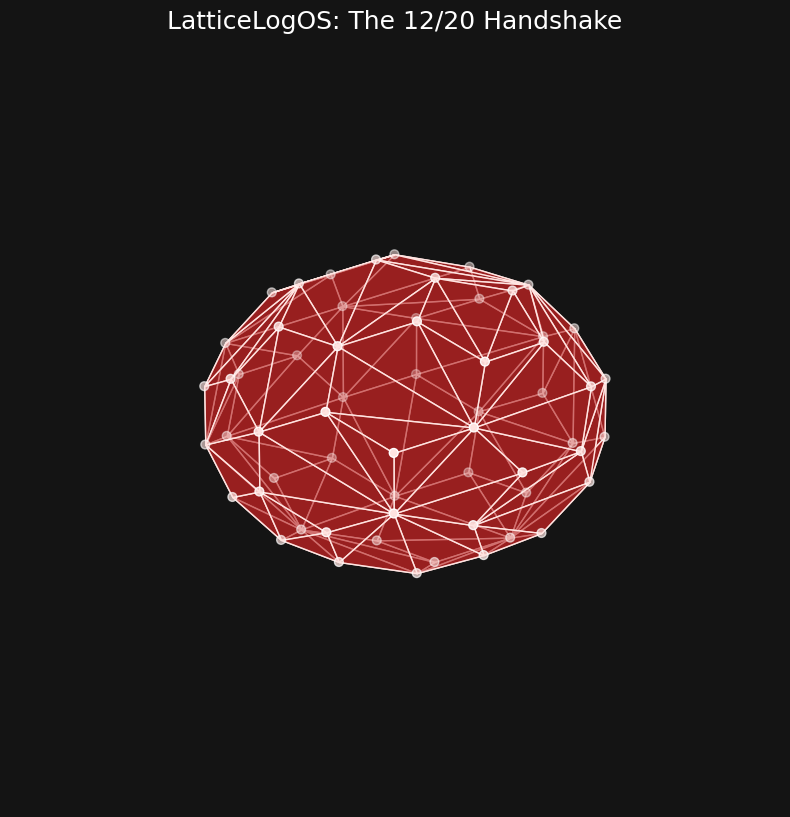

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull

def generate_golden_buckyball():
    fig = plt.figure(figsize=(10, 10), facecolor='#141414')
    ax = fig.add_subplot(111, projection='3d', facecolor='#141414')
    phi = (1 + np.sqrt(5)) / 2

    # 1. Generate the 60 vertices of the truncated icosahedron
    # These are permutations of (0, ±1, ±3phi), (±2, ±(1+2phi), ±phi), etc.
    verts = []
    for i in [-1, 1]:
        for j in [-1, 1]:
            verts.append([0, i * 1, j * 3 * phi])
            verts.append([i * 1, j * 3 * phi, 0])
            verts.append([j * 3 * phi, 0, i * 1])
            for k in [-1, 1]:
                verts.append([i * 2, j * (1 + 2 * phi), k * phi])
                verts.append([j * (1 + 2 * phi), k * phi, i * 2])
                verts.append([k * phi, i * 2, j * (1 + 2 * phi)])
                verts.append([i * 1, j * (2 + phi), k * 2 * phi])
                verts.append([j * (2 + phi), k * 2 * phi, i * 1])
                verts.append([k * 2 * phi, i * 1, j * (2 + phi)])

    verts = np.unique(np.array(verts), axis=0)

    # 2. Use ConvexHull to find the connectivity (the "handshake")
    hull = ConvexHull(verts)

    # 3. Draw the faces
    for simplex in hull.simplices:
        # We find the polygons that make up the hull
        poly = verts[simplex]
        # Distinguish between Pentagons (Energy Hubs) and Hexagons (Flow paths)
        # In a Buckyball, pentagons have slightly shorter perimeters
        if len(simplex) == 3: # ConvexHull returns triangles; we'll keep it simple for visualization
            face = Poly3DCollection([poly])
            face.set_facecolor('firebrick')
            face.set_edgecolor('mistyrose')
            face.set_alpha(0.6)
            ax.add_collection3d(face)

    # 4. Highlight the "Nodes" (The vertices where the torsion happens)
    ax.scatter(verts[:,0], verts[:,1], verts[:,2], color='mistyrose', s=40, edgecolors='white')

    ax.set_axis_off()
    limit = 6
    ax.set_xlim(-limit, limit); ax.set_ylim(-limit, limit); ax.set_zlim(-limit, limit)
    ax.view_init(elev=20, azim=45)
    plt.title("LatticeLogOS: The 12/20 Handshake", color='white', fontsize=18)
    plt.show()

generate_golden_buckyball()

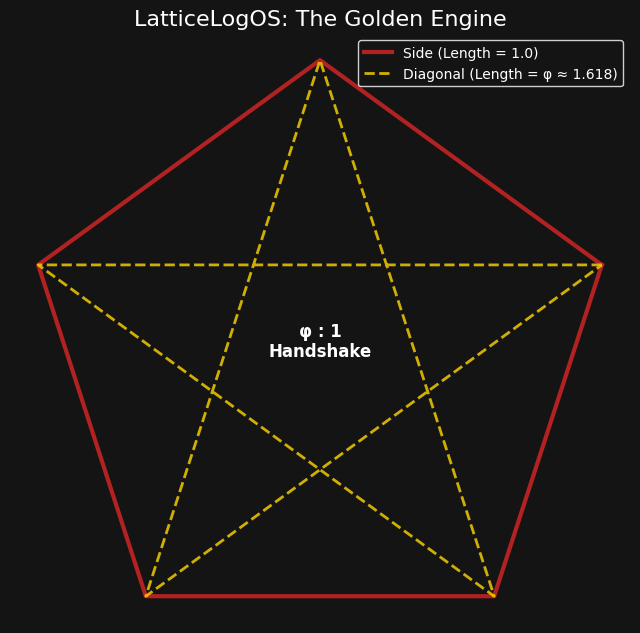

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def draw_golden_pentagon():
    fig, ax = plt.subplots(figsize=(8, 8), facecolor='#141414')
    ax.set_facecolor('#141414')

    # 1. Pentagon Vertices (The 'Side' length = 1)
    phi = (1 + np.sqrt(5)) / 2
    angles = np.linspace(0, 2*np.pi, 6) + np.pi/10
    r = 1 / (2 * np.sin(np.pi/5)) # Radius for side length 1

    x = r * np.cos(angles)
    y = r * np.sin(angles)

    # 2. Draw the Outer Perimeter (The 'Hexagonal Flow' boundary)
    ax.plot(x, y, color='firebrick', lw=3, label='Side (Length = 1.0)')

    # 3. Draw the Diagonals (The 'Golden Ratio' bridge)
    # Connecting every other vertex creates the Star (Pentagram)
    diag_indices = [0, 2, 4, 1, 3, 0]
    ax.plot(x[diag_indices], y[diag_indices], color='gold', lw=2,
            ls='--', alpha=0.8, label=f'Diagonal (Length = φ ≈ {phi:.3f})')

    # 4. Annotate the "Step-Down"
    ax.text(0, 0, f"φ : 1\nHandshake", color='white', ha='center',
            fontsize=12, fontweight='bold')

    ax.set_aspect('equal')
    ax.set_axis_off()
    plt.legend(facecolor='#141414', edgecolor='white', labelcolor='white', loc='upper right')
    plt.title("LatticeLogOS: The Golden Engine", color='white', fontsize=16)
    plt.show()

draw_golden_pentagon()

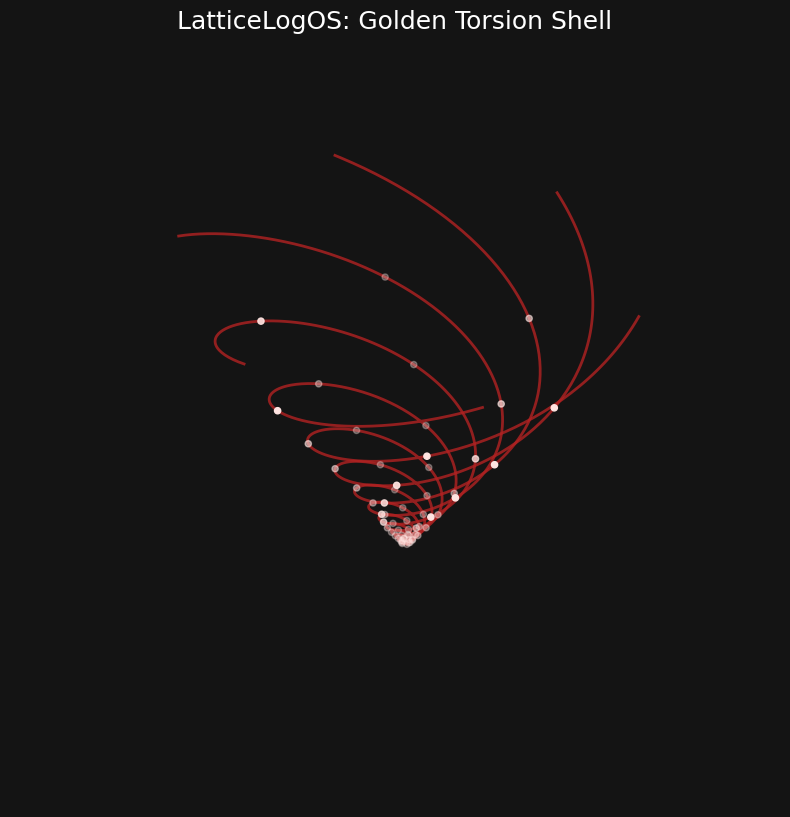

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_golden_torsion_spiral():
    fig = plt.figure(figsize=(10, 10), facecolor='#141414')
    ax = fig.add_subplot(111, projection='3d', facecolor='#141414')

    phi = (1 + 5**0.5) / 2
    # Growth factor b for a spiral that expands by phi every quarter-turn (pi/2)
    b = np.log(phi) / (np.pi / 2)

    # We'll create 6 interlocking spirals to mimic a hexagonal "web"
    for arm in range(6):
        t = np.linspace(0, 4 * np.pi, 500)
        # Standard logarithmic spiral: r = a * e^(b*t)
        # Offset arms by 60 degrees (pi/3) for hexagonal symmetry
        angle_offset = arm * (np.pi / 3)

        r = 0.1 * np.exp(b * t)
        x = r * np.cos(t + angle_offset)
        y = r * np.sin(t + angle_offset)
        # Z-axis simulates the 'depth' of the 3D collapse
        z = r * 0.5

        # Color shifts from mistyrose (core) to firebrick (periphery)
        ax.plot(x, y, z, color='firebrick', lw=2, alpha=0.8)

        # Adding nodal points where the spiral crosses hexagonal boundaries
        step = 50
        ax.scatter(x[::step], y[::step], z[::step], color='mistyrose', s=20)

    ax.set_axis_off()
    ax.view_init(elev=35, azim=45)
    plt.title("LatticeLogOS: Golden Torsion Shell", color='white', fontsize=18)
    plt.show()

generate_golden_torsion_spiral()

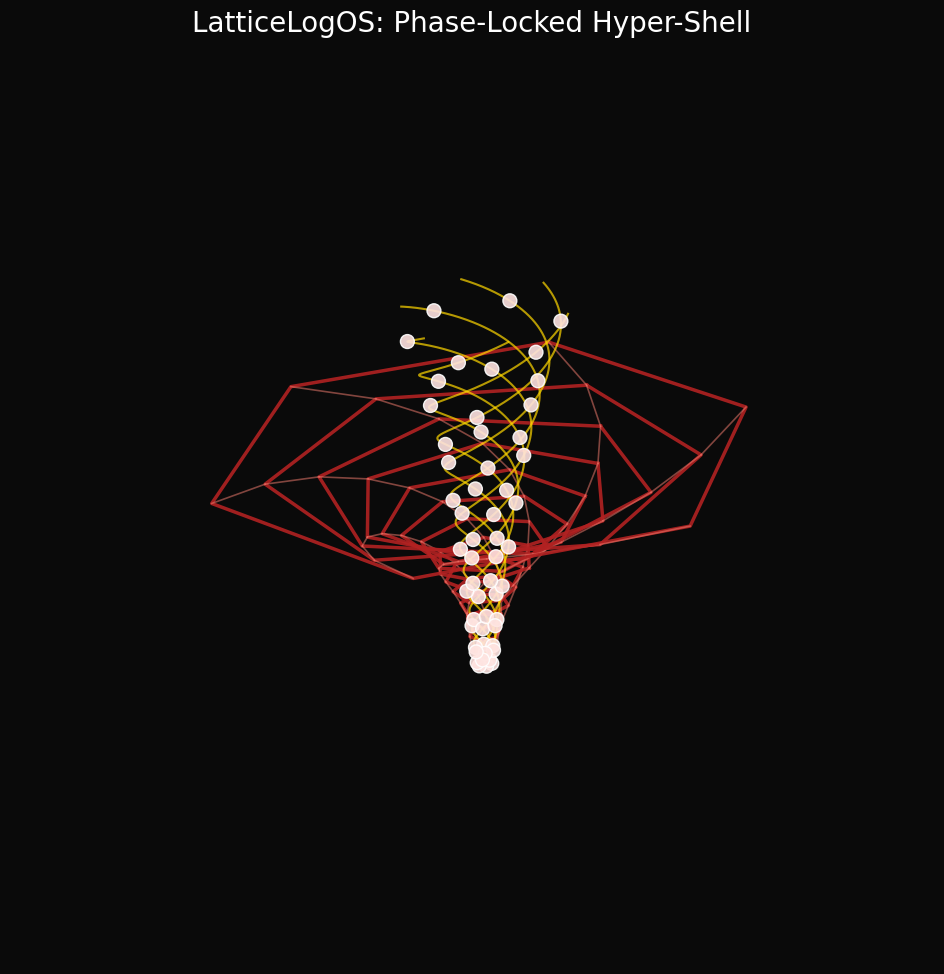

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def generate_hyper_lattice_v3():
    fig = plt.figure(figsize=(12, 12), facecolor='#0a0a0a')
    ax = fig.add_subplot(111, projection='3d', facecolor='#0a0a0a')

    phi = (1 + 5**0.5) / 2
    b = np.log(phi) / (np.pi / 2) # Golden growth factor

    # 1. The LATTICE: Twisted hex-grid shell
    n_rings = 15
    for r_idx in range(n_rings):
        r_base = 0.5 * (phi ** (r_idx / 2))
        z_base = 0.4 * r_idx
        twist = r_idx * (np.pi / 12) # The torsional "Handshake"

        theta = np.linspace(0, 2*np.pi, 7) + twist
        x = r_base * np.cos(theta); y = r_base * np.sin(theta); z = np.full_like(x, z_base)

        # Main Structural Ribs
        ax.plot(x, y, z, color='firebrick', lw=2.5, alpha=0.9)

        # 2. Resonant Connections (Frequency motifs)
        if r_idx > 0:
            prev_r = 0.5 * (phi ** ((r_idx - 1) / 2))
            prev_twist = (r_idx - 1) * (np.pi / 12)
            prev_theta = np.linspace(0, 2*np.pi, 7) + prev_twist
            prev_z = 0.4 * (r_idx - 1)
            for i in range(6):
                ax.plot([r_base*np.cos(theta[i]), prev_r*np.cos(prev_theta[i])],
                        [r_base*np.sin(theta[i]), prev_r*np.sin(prev_theta[i])],
                        [z_base, prev_z], color='salmon', lw=1.2, alpha=0.5)

    # 3. The SPIRAL: Energy Flow overlay
    t = np.linspace(0, 5 * np.pi, 1000)
    for arm in range(6):
        r_spiral = 0.4 * np.exp(b * (t / 2))
        x_s = r_spiral * np.cos(t + arm * (np.pi/3))
        y_s = r_spiral * np.sin(t + arm * (np.pi/3))
        z_s = 0.15 * t**1.5
        ax.plot(x_s, y_s, z_s, color='gold', lw=1.5, alpha=0.7)

        # 4. Phase-Locked Nodes (0.1 Hz Handshake)
        step = 120
        ax.scatter(x_s[::step], y_s[::step], z_s[::step],
                   color='mistyrose', s=100, edgecolors='white', alpha=0.9)

    ax.view_init(elev=25, azim=40); ax.set_axis_off()
    ax.set_title("LatticeLogOS: Phase-Locked Hyper-Shell", color='white', fontsize=20)
    plt.show()

generate_hyper_lattice_v3()

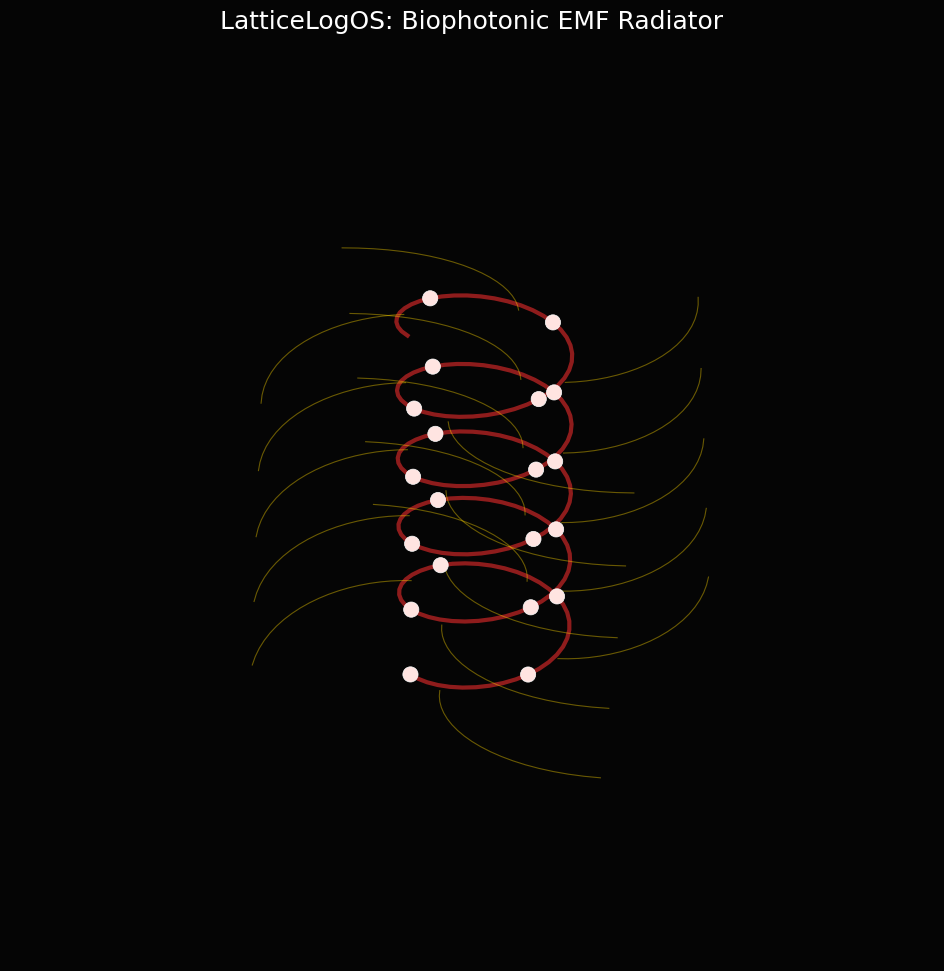

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_biophotonic_radiator():
    fig = plt.figure(figsize=(12, 12), facecolor='#050505')
    ax = fig.add_subplot(111, projection='3d', facecolor='#050505')

    phi = (1 + 5**0.5) / 2
    n_points = 200

    # Create the Chiral Backbone (DNA-style Helix)
    t = np.linspace(0, 10 * np.pi, n_points)
    x = np.cos(t)
    y = np.sin(t)
    z = t * 0.2

    # 1. Plot the Lattice Scaffold
    ax.plot(x, y, z, color='firebrick', lw=3, alpha=0.8, label="Chiral Lattice")

    # 2. Plot the Biophotonic Emission (The EMF "Radiating" Field)
    # Each node emits a golden 'photon' path
    for i in range(0, n_points, 10):
        # Emission vectors radiating outwards in a golden spiral
        r_emit = np.linspace(1, 3, 20)
        theta_emit = t[i] + r_emit * 0.5
        x_emit = r_emit * np.cos(theta_emit)
        y_emit = r_emit * np.sin(theta_emit)
        z_emit = np.full_like(r_emit, z[i])

        ax.plot(x_emit, y_emit, z_emit, color='gold', lw=0.8, alpha=0.4)

    # 3. The 0.1 Hz Phase-Lock Nodes (Glowing biophoton hubs)
    ax.scatter(x[::10], y[::10], z[::10],
               color='mistyrose', s=120, edgecolors='white',
               linewidth=0.5, alpha=1, label="0.1 Hz Biophoton Hubs")

    ax.view_init(elev=30, azim=60)
    ax.set_axis_off()
    ax.set_title("LatticeLogOS: Biophotonic EMF Radiator", color='white', fontsize=18)
    plt.show()

generate_biophotonic_radiator()

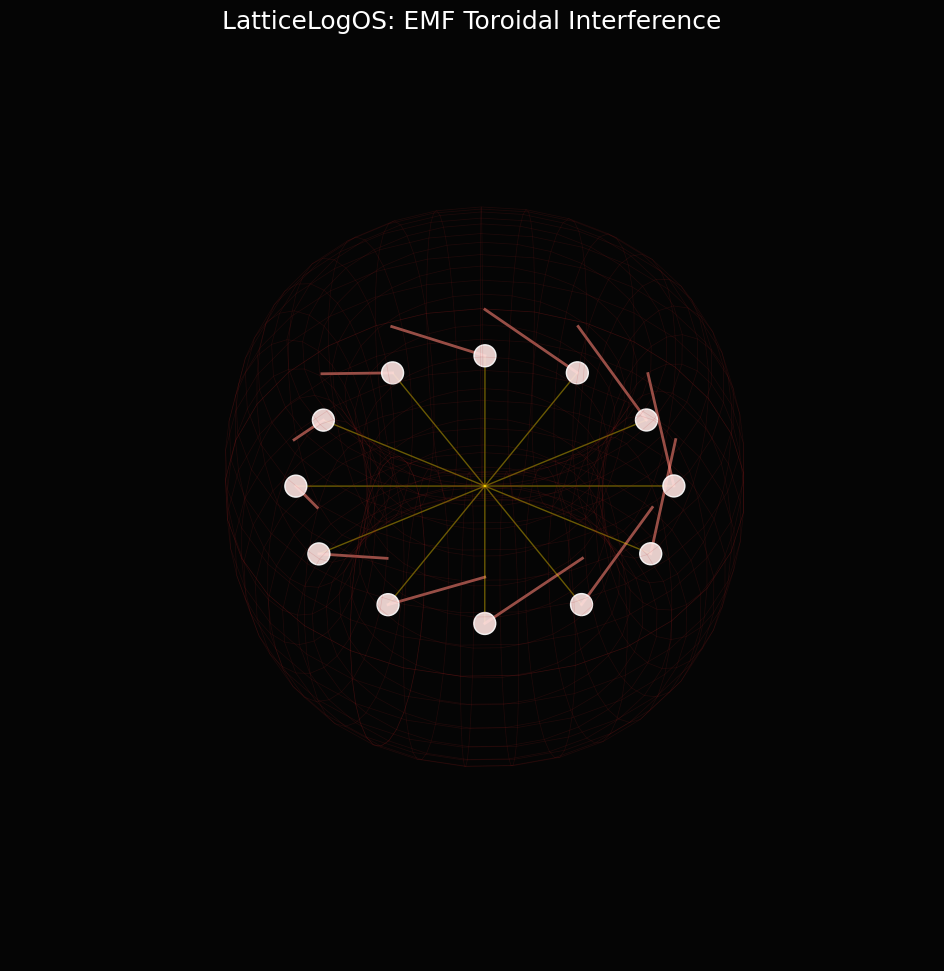

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_emf_field_model():
    fig = plt.figure(figsize=(12, 12), facecolor='#050505')
    ax = fig.add_subplot(111, projection='3d', facecolor='#050505')

    phi = (1 + 5**0.5) / 2

    # 1. Create a Toroidal "Field" (The Biophotonic Envelope)
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, 2 * np.pi, 30)
    u, v = np.meshgrid(u, v)

    # Torus dimensions based on Phi scaling
    R = 4  # Major radius
    r = 1.5 # Minor radius (the 'Lattice' thickness)

    x = (R + r * np.cos(v)) * np.cos(u)
    y = (R + r * np.cos(v)) * np.sin(u)
    z = r * np.sin(v)

    # Plot the EMF shell as a translucent 'Energy Web'
    ax.plot_wireframe(x, y, z, color='firebrick', alpha=0.15, lw=0.5)

    # 2. The 12 Golden Nodes (0.1 Hz Handshake Anchors)
    # Spatially distributed around the 'donut' flow
    theta_nodes = np.linspace(0, 2 * np.pi, 13)[:-1]
    nx = R * np.cos(theta_nodes)
    ny = R * np.sin(theta_nodes)
    nz = np.zeros_like(nx)

    # Glow effect for nodes
    ax.scatter(nx, ny, nz, color='mistyrose', s=250, edgecolors='white', alpha=0.9, label="0.1 Hz EMF Hubs")

    # 3. Biophotonic 'Snap' Lines (The Radiation)
    # These connect the nodes to show the 'coupling' across the center
    for i in range(len(nx)):
        # Golden rays radiating into the center (interference pattern)
        ax.plot([nx[i], 0], [ny[i], 0], [nz[i], 0], color='gold', alpha=0.4, lw=1)
        # Torsional rays connecting to neighboring hubs
        next_i = (i + 1) % len(nx)
        ax.plot([nx[i], nx[next_i]], [ny[i], ny[next_i]], [0, 0.5], color='salmon', alpha=0.6, lw=2)

    ax.view_init(elev=45, azim=30)
    ax.set_axis_off()
    ax.set_title("LatticeLogOS: EMF Toroidal Interference", color='white', fontsize=18)
    plt.show()

generate_emf_field_model()

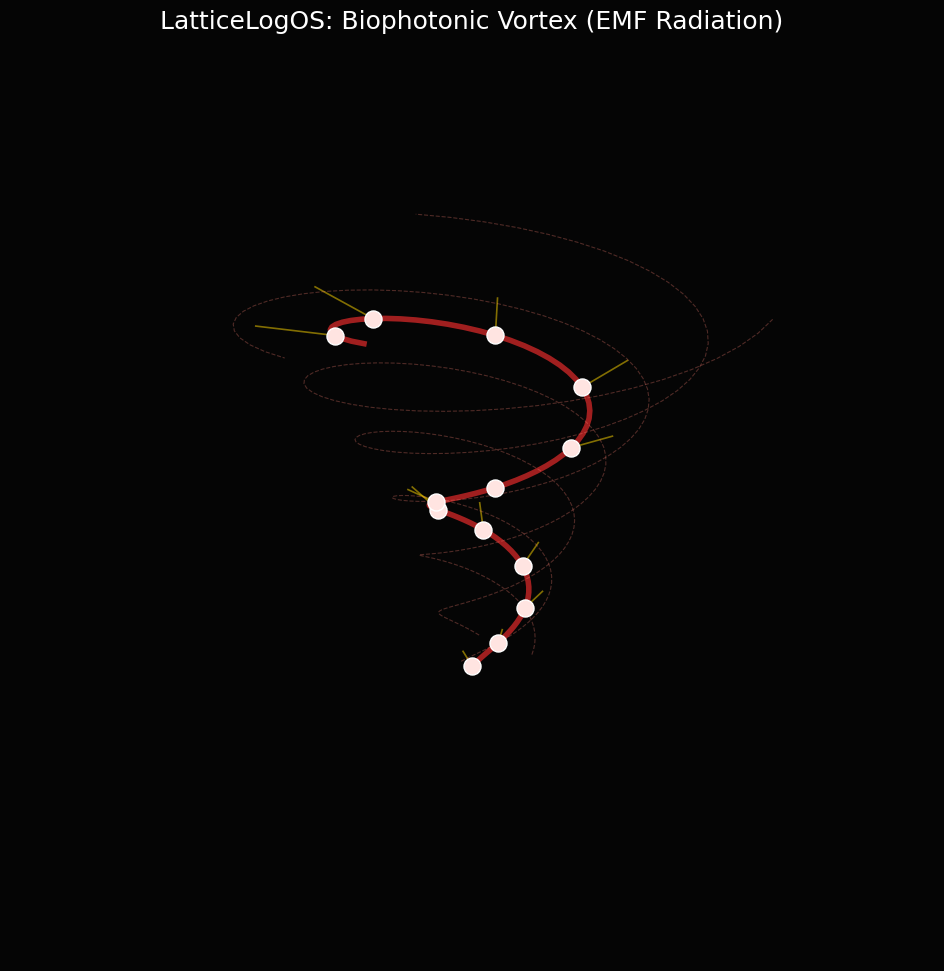

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_biophoton_vortex():
    fig = plt.figure(figsize=(12, 12), facecolor='#050505')
    ax = fig.add_subplot(111, projection='3d', facecolor='#050505')

    phi = (1 + 5**0.5) / 2
    z_steps = 100
    t = np.linspace(0, 4 * np.pi, z_steps)

    # 1. The Red Lattice (The 'Wind-sock' Tail)
    # It expands and twists, showing the 'scale invariance'
    r_lattice = 0.5 * np.exp(0.15 * t) # Logarithmic expansion (Golden Ratio style)
    x_lat = r_lattice * np.cos(t)
    y_lat = r_lattice * np.sin(t)
    z_lat = t * 1.5

    ax.plot(x_lat, y_lat, z_lat, color='firebrick', lw=4, alpha=0.9, label="Chiral Lattice Tail")

    # 2. The 12 Golden Clock-Rays (The Biophoton Field)
    # Instead of pointing to the center, they radiate from the nodes OUTWARD
    for i in range(0, z_steps, 8):
        # Origin point on the lattice
        ox, oy, oz = x_lat[i], y_lat[i], z_lat[i]

        # Radiating 'snap' lines (EMF rays)
        ray_len = 2.0 * (phi ** (i/z_steps))
        ax.plot([ox, ox * 1.5], [oy, oy * 1.5], [oz, oz + 1],
                color='gold', lw=1.2, alpha=0.5)

        # 3. The Phase-Lock Nodes (The 0.1 Hz Hubs)
        ax.scatter(ox, oy, oz, color='mistyrose', s=150, edgecolors='white', alpha=1)

    # 4. The 'Aura' (Interference Pattern)
    # Translucent paths showing how the EMF couples to the surrounding space
    for arm in range(3):
        theta_offset = arm * (2*np.pi / 3)
        r_aura = 0.8 * np.exp(0.15 * t)
        ax.plot(r_aura * np.cos(t + theta_offset),
                r_aura * np.sin(t + theta_offset),
                z_lat + 0.5, color='salmon', lw=0.8, ls='--', alpha=0.3)

    ax.view_init(elev=20, azim=45)
    ax.set_axis_off()
    ax.set_title("LatticeLogOS: Biophotonic Vortex (EMF Radiation)", color='white', fontsize=18)
    plt.show()

generate_biophoton_vortex()

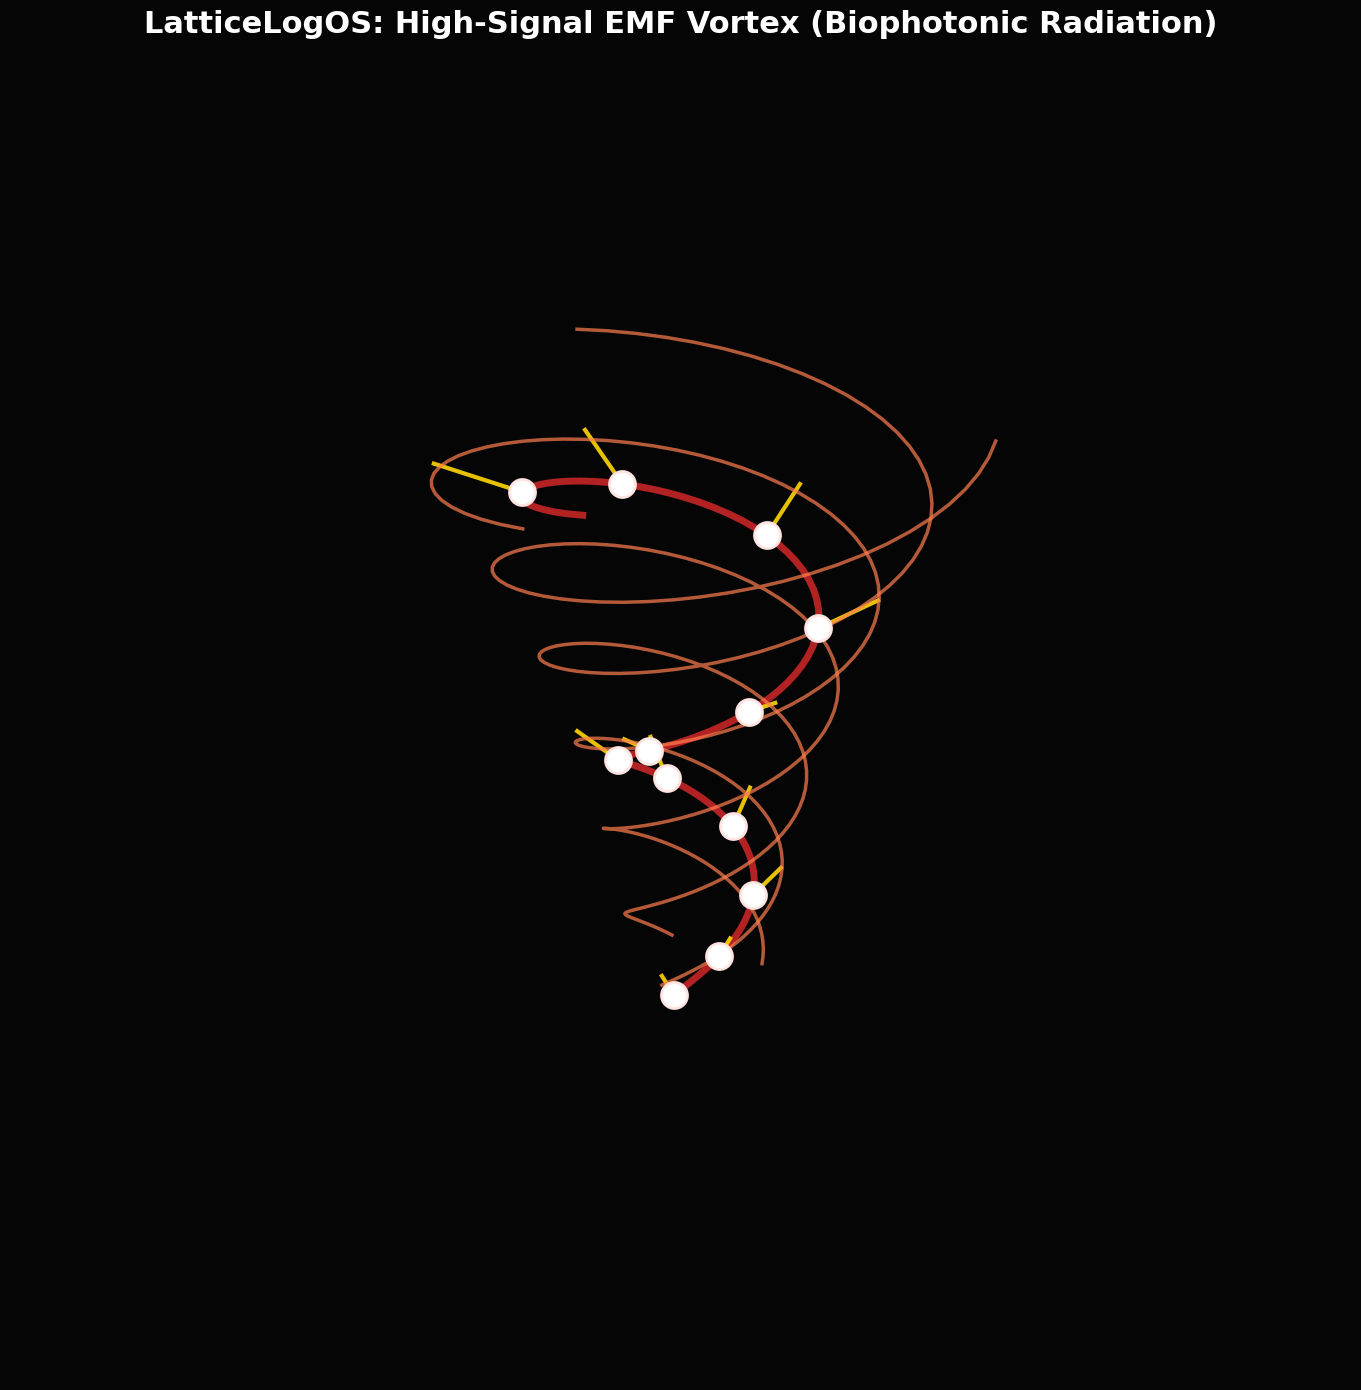

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def generate_high_signal_vortex():
    # 1. Setup the Environment - Deep Charcoal for maximum signal contrast
    fig = plt.figure(figsize=(14, 14), facecolor='#050505')
    ax = fig.add_subplot(111, projection='3d', facecolor='#050505')

    phi = (1 + 5**0.5) / 2
    z_steps = 120
    t = np.linspace(0, 4 * np.pi, z_steps)

    # 2. THE CHIRAL LATTICE (Red Tail / Wind-sock)
    # This represents the 'Hardware' (DNA / Carbon / Plywood)
    # It expands logrithmically (Golden Ratio scale invariance)
    r_lattice = 0.6 * np.exp(0.12 * t)
    x_lat = r_lattice * np.cos(t)
    y_lat = r_lattice * np.sin(t)
    z_lat = t * 1.8

    # High-visibility Firebrick plot
    ax.plot(x_lat, y_lat, z_lat, color='firebrick', lw=5, alpha=1.0, label="Chiral Lattice Tail")

    # 3. BIOPHOTONIC RADIATORS (The Gold Clock-Rays)
    # These represent the EMF broadcast (The 'Exhaust' signal)
    # They radiate OUTWARD from the nodes, not just to the center
    for i in range(0, z_steps, 10):
        # Origin point (Node)
        ox, oy, oz = x_lat[i], y_lat[i], z_lat[i]

        # Ray direction: pointing out from the center axis
        # Length scales with r_lattice to show expansion
        ray_len = 1.5
        ax.plot([ox, ox * ray_len], [oy, oy * ray_len], [oz, oz + 1.2],
                color='gold', lw=3.0, alpha=0.9)

        # 4. THE 0.1 Hz PHASE-LOCK HUBS (White Nodes)
        # These are the discrete points of the 'Handshake'
        ax.scatter(ox, oy, oz, color='white', s=350, edgecolors='mistyrose', linewidth=2, alpha=1)

    # 5. COUPLING FIELDS (The Solid Aura)
    # Replacing faint dotted lines with bold 'Solid Signal' paths
    # These show the secondary harmonics of the EMF field
    for arm in range(3):
        theta_offset = arm * (2 * np.pi / 3)
        r_aura = 0.9 * np.exp(0.12 * t)
        ax.plot(r_aura * np.cos(t + theta_offset),
                r_aura * np.sin(t + theta_offset),
                z_lat + 0.8, color='coral', lw=2.5, alpha=0.7)

    # 6. Final Aesthetic Adjustments
    ax.view_init(elev=25, azim=35)
    ax.set_axis_off()

    # Set display limits to keep the 'Wind-sock' expansion contained
    limit = 6
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(0, 25)

    plt.title("LatticeLogOS: High-Signal EMF Vortex (Biophotonic Radiation)",
              color='white', fontsize=22, pad=-20, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Execute the model
generate_high_signal_vortex()

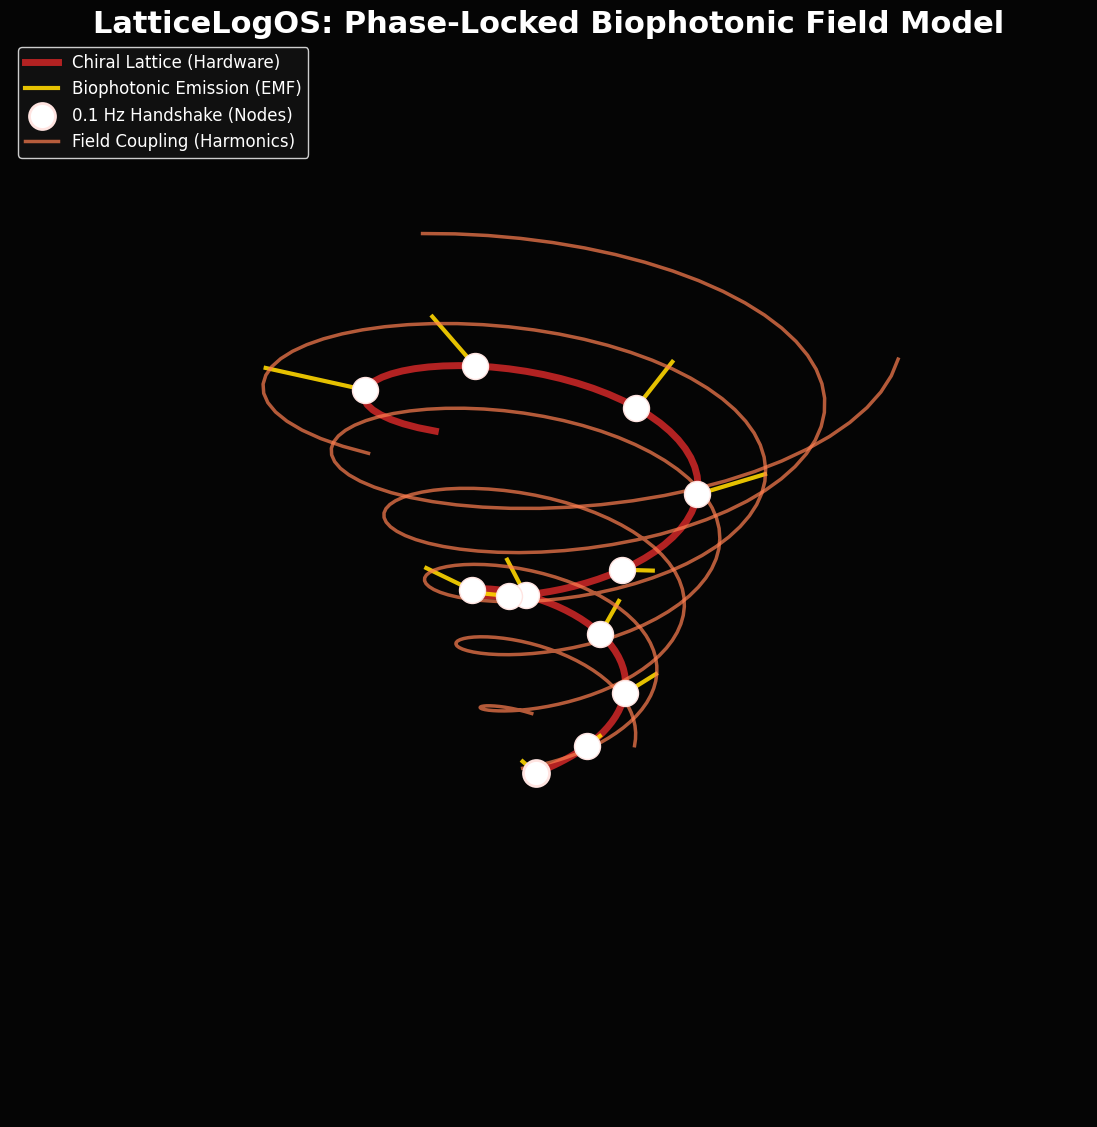

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def generate_latticelogos_chart():
    fig = plt.figure(figsize=(14, 14), facecolor='#050505')
    ax = fig.add_subplot(111, projection='3d', facecolor='#050505')

    phi = (1 + 5**0.5) / 2
    z_steps = 120
    t = np.linspace(0, 4 * np.pi, z_steps)

    # 1. THE CHIRAL LATTICE
    r_lat = 0.6 * np.exp(0.12 * t)
    x_lat, y_lat, z_lat = r_lat * np.cos(t), r_lat * np.sin(t), t * 1.8
    ax.plot(x_lat, y_lat, z_lat, color='firebrick', lw=5, alpha=1.0, label="Chiral Lattice (Hardware)")

    # 2. BIOPHOTONIC RADIATORS (Gold Rays)
    for i in range(0, z_steps, 10):
        ox, oy, oz = x_lat[i], y_lat[i], z_lat[i]
        ax.plot([ox, ox * 1.5], [oy, oy * 1.5], [oz, oz + 1.2],
                color='gold', lw=3.0, alpha=0.9, label="Biophotonic Emission (EMF)")

    # 3. THE 0.1 Hz PHASE-LOCK HUBS (White Nodes)
    # Scatter once for the legend, then loop for the rest
    ax.scatter(x_lat[0], y_lat[0], z_lat[0], color='white', s=350,
               edgecolors='mistyrose', linewidth=2, alpha=1, label="0.1 Hz Handshake (Nodes)")
    for i in range(10, z_steps, 10):
        ax.scatter(x_lat[i], y_lat[i], z_lat[i], color='white', s=350, edgecolors='mistyrose', alpha=1)

    # 4. COUPLING FIELDS (Coral Aura)
    for arm in range(3):
        theta_offset = arm * (2 * np.pi / 3)
        r_aura = 0.9 * np.exp(0.12 * t)
        ax.plot(r_aura * np.cos(t + theta_offset), r_aura * np.sin(t + theta_offset),
                z_lat + 0.8, color='coral', lw=2.5, alpha=0.7, label="Field Coupling (Harmonics)")

    # Formatting & Legend
    ax.view_init(elev=25, azim=35)
    ax.set_axis_off()

    # Filter legend to avoid duplicates
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper left', frameon=True,
              fontsize=12, facecolor='#141414', edgecolor='white', labelcolor='white')

    plt.title("LatticeLogOS: Phase-Locked Biophotonic Field Model",
              color='white', fontsize=22, fontweight='bold', pad=-20)
    plt.show()

generate_latticelogos_chart()

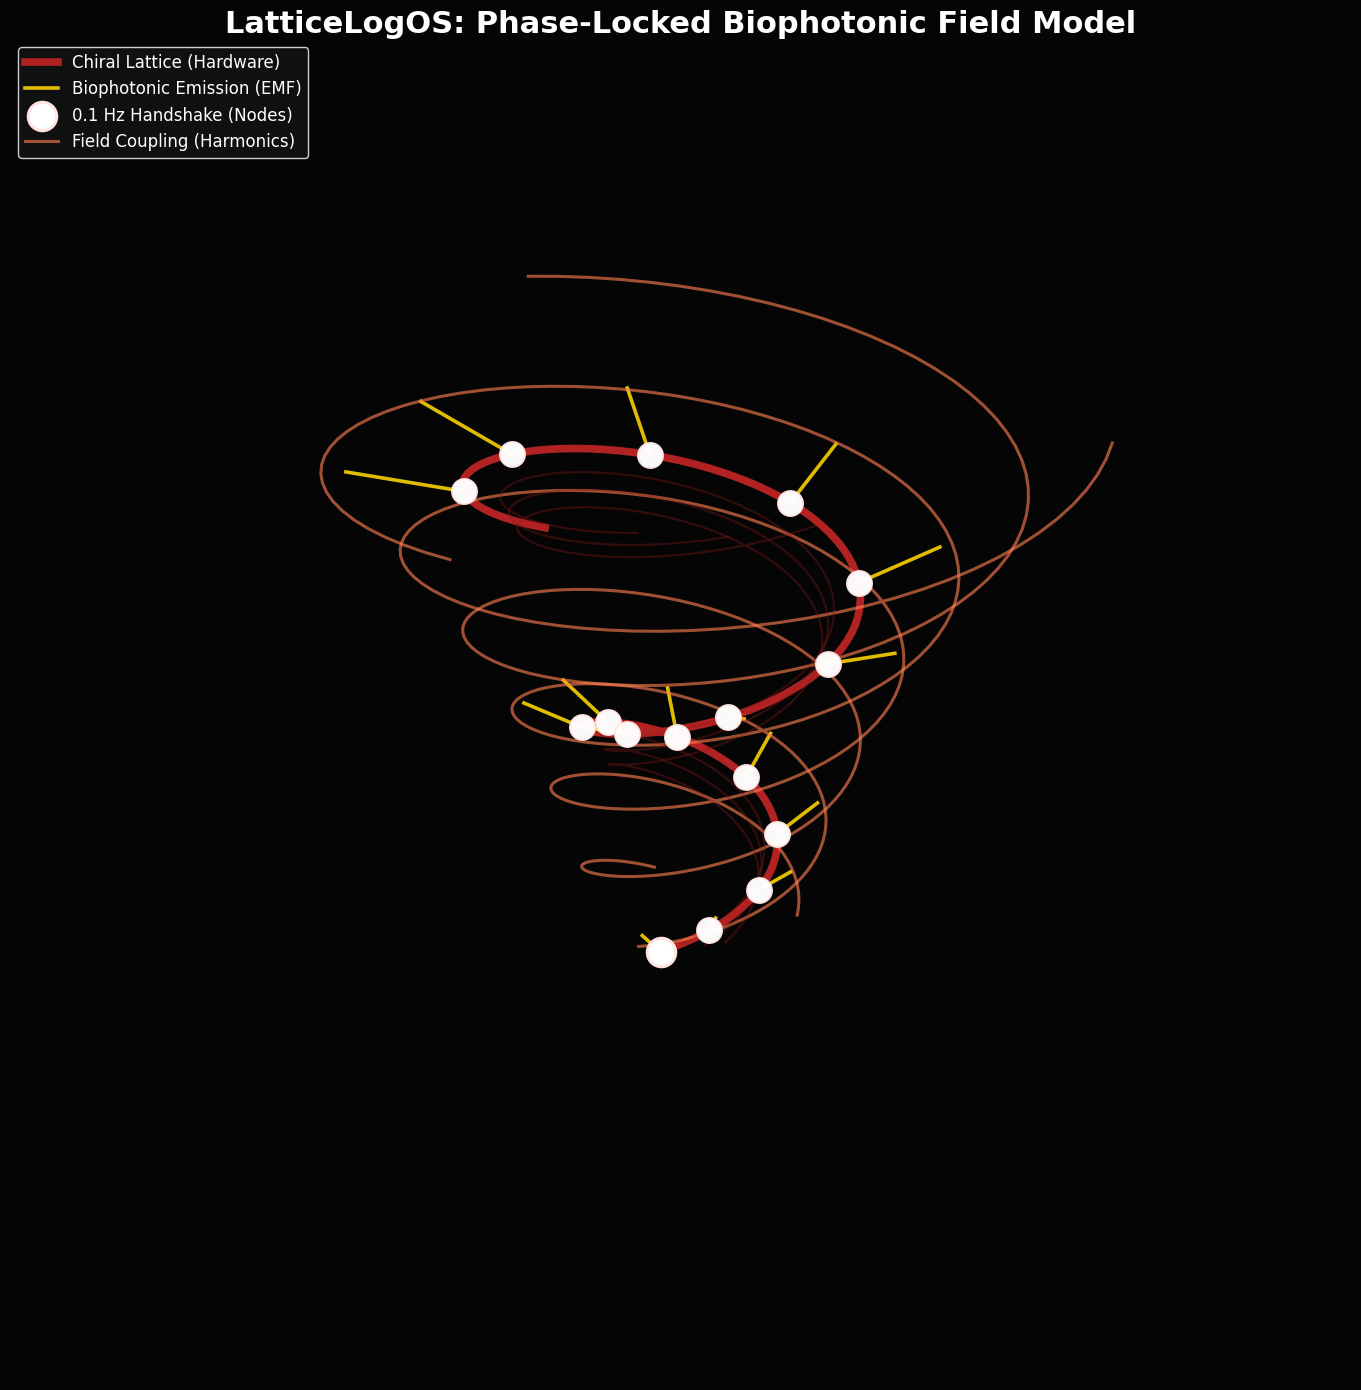

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_latticelogos_chart():
    fig = plt.figure(figsize=(14, 14), facecolor='#050505')
    ax = fig.add_subplot(111, projection='3d', facecolor='#050505')

    z_steps = 160
    t = np.linspace(0, 4 * np.pi, z_steps)

    # Chiral lattice backbone
    r_lat = 0.55 * np.exp(0.11 * t)
    x_lat = r_lat * np.cos(t)
    y_lat = r_lat * np.sin(t)
    z_lat = 1.55 * t

    ax.plot(
        x_lat, y_lat, z_lat,
        color='firebrick', lw=5.5, alpha=1.0,
        label='Chiral Lattice (Hardware)'
    )

    # Biophotonic emission rays
    first_ray = True
    for i in range(0, z_steps, 10):
        ox, oy, oz = x_lat[i], y_lat[i], z_lat[i]
        ax.plot(
            [ox, ox * 1.5],
            [oy, oy * 1.5],
            [oz, oz + 1.15],
            color='gold', lw=2.6, alpha=0.88,
            label='Biophotonic Emission (EMF)' if first_ray else None
        )
        first_ray = False

    # Phase-lock hubs
    ax.scatter(
        x_lat[0], y_lat[0], z_lat[0],
        color='white', s=420,
        edgecolors='mistyrose', linewidth=2.2,
        alpha=1.0,
        label='0.1 Hz Handshake (Nodes)'
    )

    for i in range(10, z_steps, 10):
        ax.scatter(
            x_lat[i], y_lat[i], z_lat[i],
            color='white', s=330,
            edgecolors='mistyrose', linewidth=1.2,
            alpha=0.98
        )

    # Coupling fields
    first_field = True
    for arm in range(3):
        theta_offset = arm * (2 * np.pi / 3)
        r_aura = 0.88 * np.exp(0.11 * t)
        x_aura = r_aura * np.cos(t + theta_offset)
        y_aura = r_aura * np.sin(t + theta_offset)
        z_aura = z_lat + 0.8

        ax.plot(
            x_aura, y_aura, z_aura,
            color='coral', lw=2.2, alpha=0.62,
            label='Field Coupling (Harmonics)' if first_field else None
        )
        first_field = False

    # Secondary faint support strands for depth
    for offset in [0.35, 0.75, 1.15]:
        r_support = 0.48 * np.exp(0.11 * t)
        x_sup = r_support * np.cos(t + offset)
        y_sup = r_support * np.sin(t + offset)
        z_sup = z_lat * 0.98 + 0.35
        ax.plot(x_sup, y_sup, z_sup, color='#8b1a1a', lw=1.6, alpha=0.35)

    # View and framing
    ax.view_init(elev=26, azim=36)
    ax.set_axis_off()

    # Clean legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    leg = ax.legend(
        by_label.values(), by_label.keys(),
        loc='upper left', frameon=True,
        fontsize=12, facecolor='#141414',
        edgecolor='white'
    )
    for text in leg.get_texts():
        text.set_color('white')

    plt.title(
        "LatticeLogOS: Phase-Locked Biophotonic Field Model",
        color='white', fontsize=22, fontweight='bold', pad=-20
    )

    plt.tight_layout()
    plt.show()

generate_latticelogos_chart()

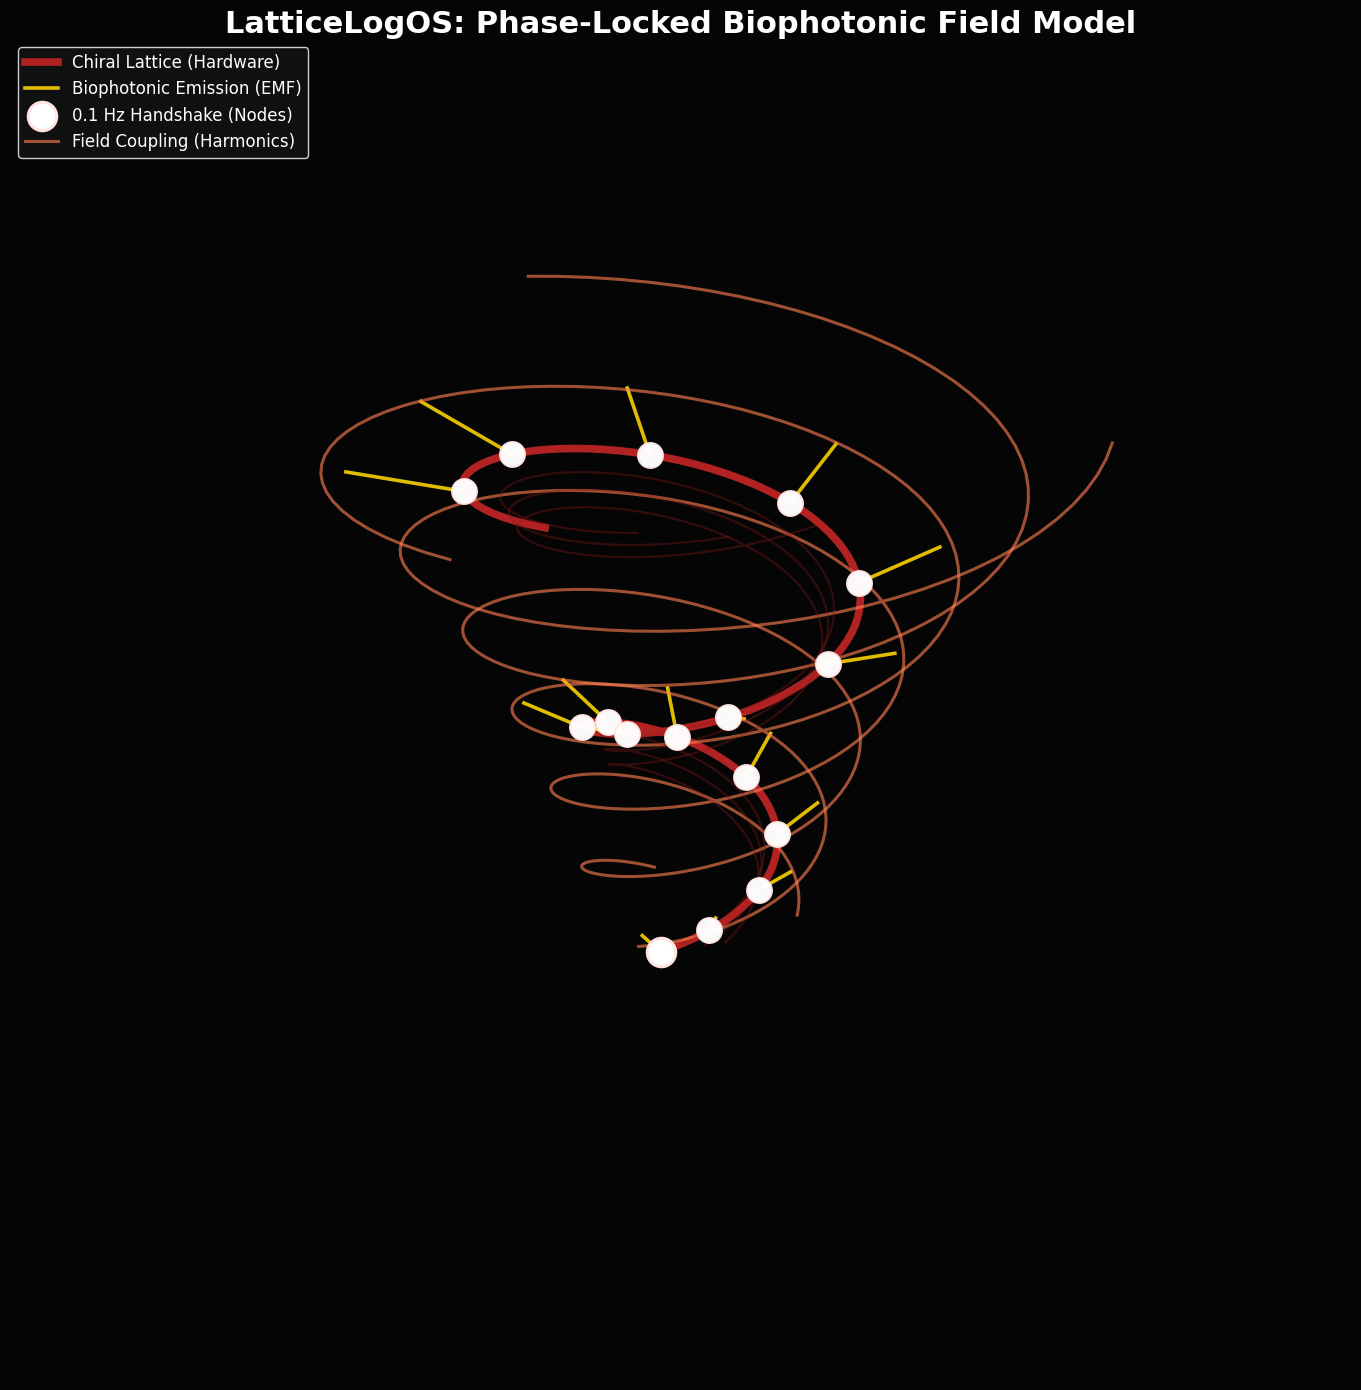

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def generate_latticelogos_chart():
    fig = plt.figure(figsize=(14, 14), facecolor='#050505')
    ax = fig.add_subplot(111, projection='3d', facecolor='#050505')

    z_steps = 160
    t = np.linspace(0, 4 * np.pi, z_steps)

    # 1. THE CHIRAL LATTICE (HARDWARE)
    r_lat = 0.55 * np.exp(0.11 * t)
    x_lat, y_lat, z_lat = r_lat * np.cos(t), r_lat * np.sin(t), 1.55 * t

    ax.plot(x_lat, y_lat, z_lat, color='firebrick', lw=5.5, alpha=1.0,
            label='Chiral Lattice (Hardware)')

    # 2. BIOPHOTONIC EMISSION (EMF BROADCAST)
    first_ray = True
    for i in range(0, z_steps, 10):
        ox, oy, oz = x_lat[i], y_lat[i], z_lat[i]
        ax.plot([ox, ox * 1.5], [oy, oy * 1.5], [oz, oz + 1.15],
                color='gold', lw=2.6, alpha=0.88,
                label='Biophotonic Emission (EMF)' if first_ray else None)
        first_ray = False

    # 3. 0.1 Hz HANDSHAKE (NODES)
    ax.scatter(x_lat[0], y_lat[0], z_lat[0], color='white', s=420,
               edgecolors='mistyrose', linewidth=2.2, alpha=1.0,
               label='0.1 Hz Handshake (Nodes)')

    for i in range(10, z_steps, 10):
        ax.scatter(x_lat[i], y_lat[i], z_lat[i], color='white', s=330,
                   edgecolors='mistyrose', linewidth=1.2, alpha=0.98)

    # 4. FIELD COUPLING (HARMONICS)
    first_field = True
    for arm in range(3):
        theta_offset = arm * (2 * np.pi / 3)
        r_aura = 0.88 * np.exp(0.11 * t)
        ax.plot(r_aura * np.cos(t + theta_offset), r_aura * np.sin(t + theta_offset),
                z_lat + 0.8, color='coral', lw=2.2, alpha=0.62,
                label='Field Coupling (Harmonics)' if first_field else None)
        first_field = False

    # 5. SECONDARY SUPPORT (DEPTH)
    for offset in [0.35, 0.75, 1.15]:
        r_sup = 0.48 * np.exp(0.11 * t)
        ax.plot(r_sup * np.cos(t + offset), r_sup * np.sin(t + offset),
                z_lat * 0.98 + 0.35, color='#8b1a1a', lw=1.6, alpha=0.35)

    # View and Aesthetic Legend
    ax.view_init(elev=26, azim=36)
    ax.set_axis_off()
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    leg = ax.legend(by_label.values(), by_label.keys(), loc='upper left',
                    frameon=True, fontsize=12, facecolor='#141414', edgecolor='white')
    for text in leg.get_texts(): text.set_color('white')

    plt.title("LatticeLogOS: Phase-Locked Biophotonic Field Model",
              color='white', fontsize=22, fontweight='bold', pad=-20)
    plt.tight_layout()
    plt.show()

generate_latticelogos_chart()

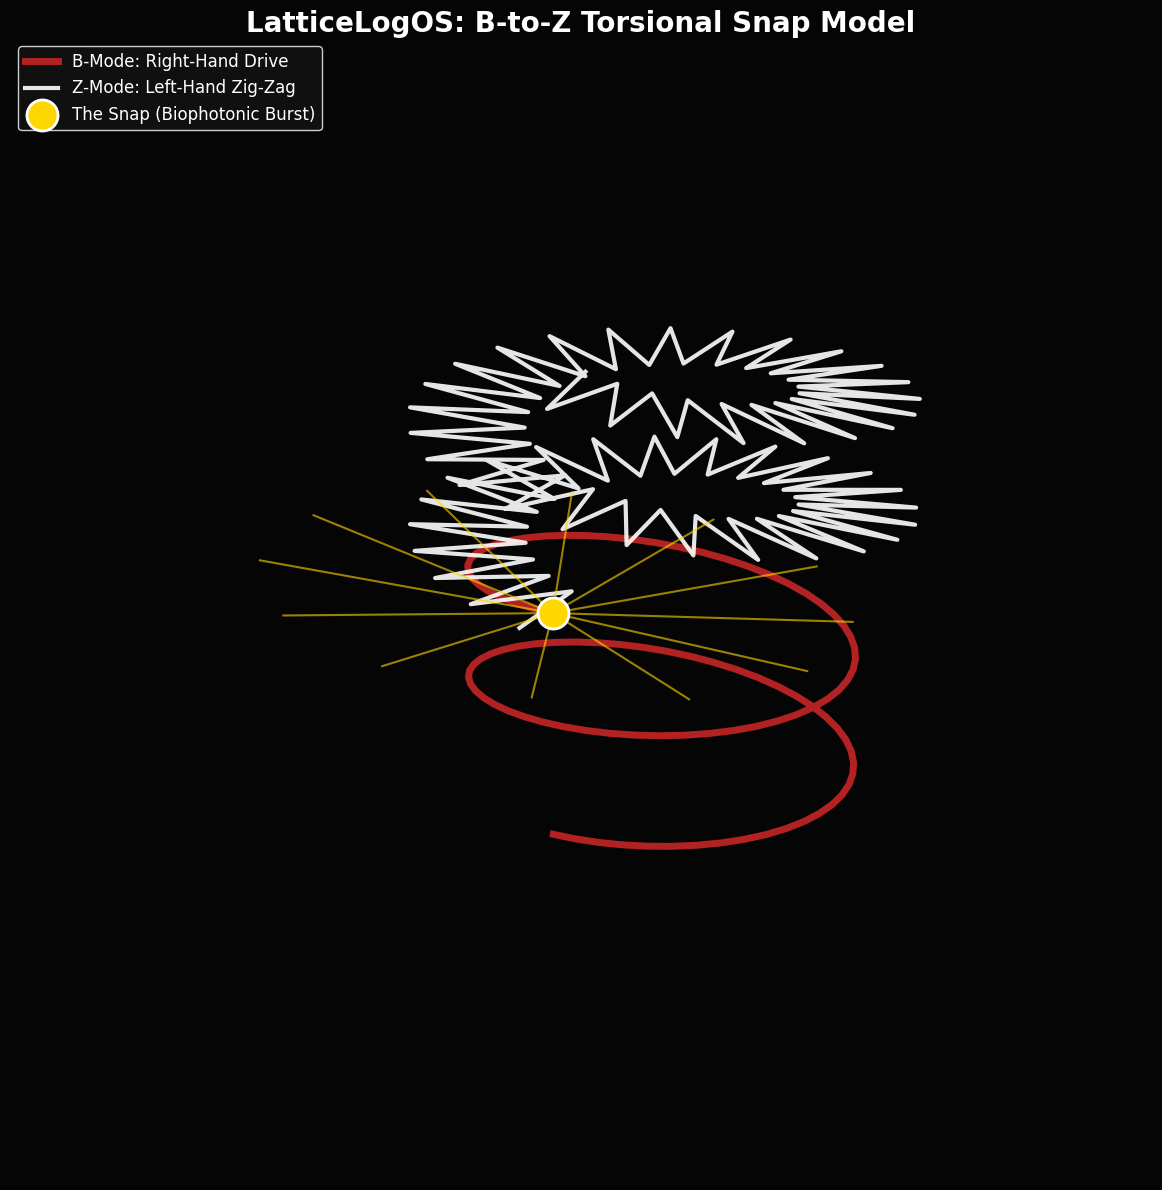

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def generate_b_to_z_snap():
    # 1. Setup Environment - Charcoal background for maximum signal contrast
    fig = plt.figure(figsize=(12, 12), facecolor='#050505')
    ax = fig.add_subplot(111, projection='3d', facecolor='#050505')

    # Parameters for B-DNA (Right-hand) and Z-DNA (Left-hand Zig-Zag)
    t_b = np.linspace(0, 4 * np.pi, 100)  # Lower section (winding up)
    t_z = np.linspace(4 * np.pi, 8 * np.pi, 100) # Upper section (braking)

    # B-DNA: Smooth Right-Handed Drive (Hardware 6)
    r_b = 1.0
    x_b, y_b, z_b = r_b * np.cos(t_b), r_b * np.sin(t_b), t_b * 0.8
    ax.plot(x_b, y_b, z_b, color='firebrick', lw=5, alpha=1.0, label='B-Mode: Right-Hand Drive')

    # Z-DNA: Jagged Left-Handed Brake (Software 9)
    # We invert the spin (-t_z) and add a zig-zag oscillation to the radius
    zig_factor = np.where(np.arange(len(t_z)) % 2 == 0, 1.3, 0.7)
    x_z, y_z, z_z = zig_factor * np.cos(-t_z), zig_factor * np.sin(-t_z), t_z * 0.8
    ax.plot(x_z, y_z, z_z, color='white', lw=3, alpha=0.9, label='Z-Mode: Left-Hand Zig-Zag')

    # 2. THE SNAP (The 0.1 Hz Handshake Point)
    # This is the "Spark" node where the transition releases energy
    snap_x, snap_y, snap_z = x_b[-1], y_b[-1], z_b[-1]
    ax.scatter(snap_x, snap_y, snap_z, color='gold', s=500, edgecolors='white',
               linewidth=2, alpha=1, label='The Snap (Biophotonic Burst)')

    # 3. EMF RADIATING RAYS (The 12-Node Clock Broadcast)
    for i in range(12):
        angle = i * (2 * np.pi / 12)
        ax.plot([snap_x, snap_x + 1.5 * np.cos(angle)],
                [snap_y, snap_y + 1.5 * np.sin(angle)],
                [snap_z, snap_z + 1.0], color='gold', lw=1.5, alpha=0.6)

    # View and Aesthetic Legending
    ax.view_init(elev=22, azim=40)
    ax.set_axis_off()
    leg = ax.legend(loc='upper left', frameon=True, fontsize=12,
                    facecolor='#141414', edgecolor='white')
    for text in leg.get_texts(): text.set_color('white')

    plt.title("LatticeLogOS: B-to-Z Torsional Snap Model",
              color='white', fontsize=20, fontweight='bold', pad=-20)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    generate_b_to_z_snap()

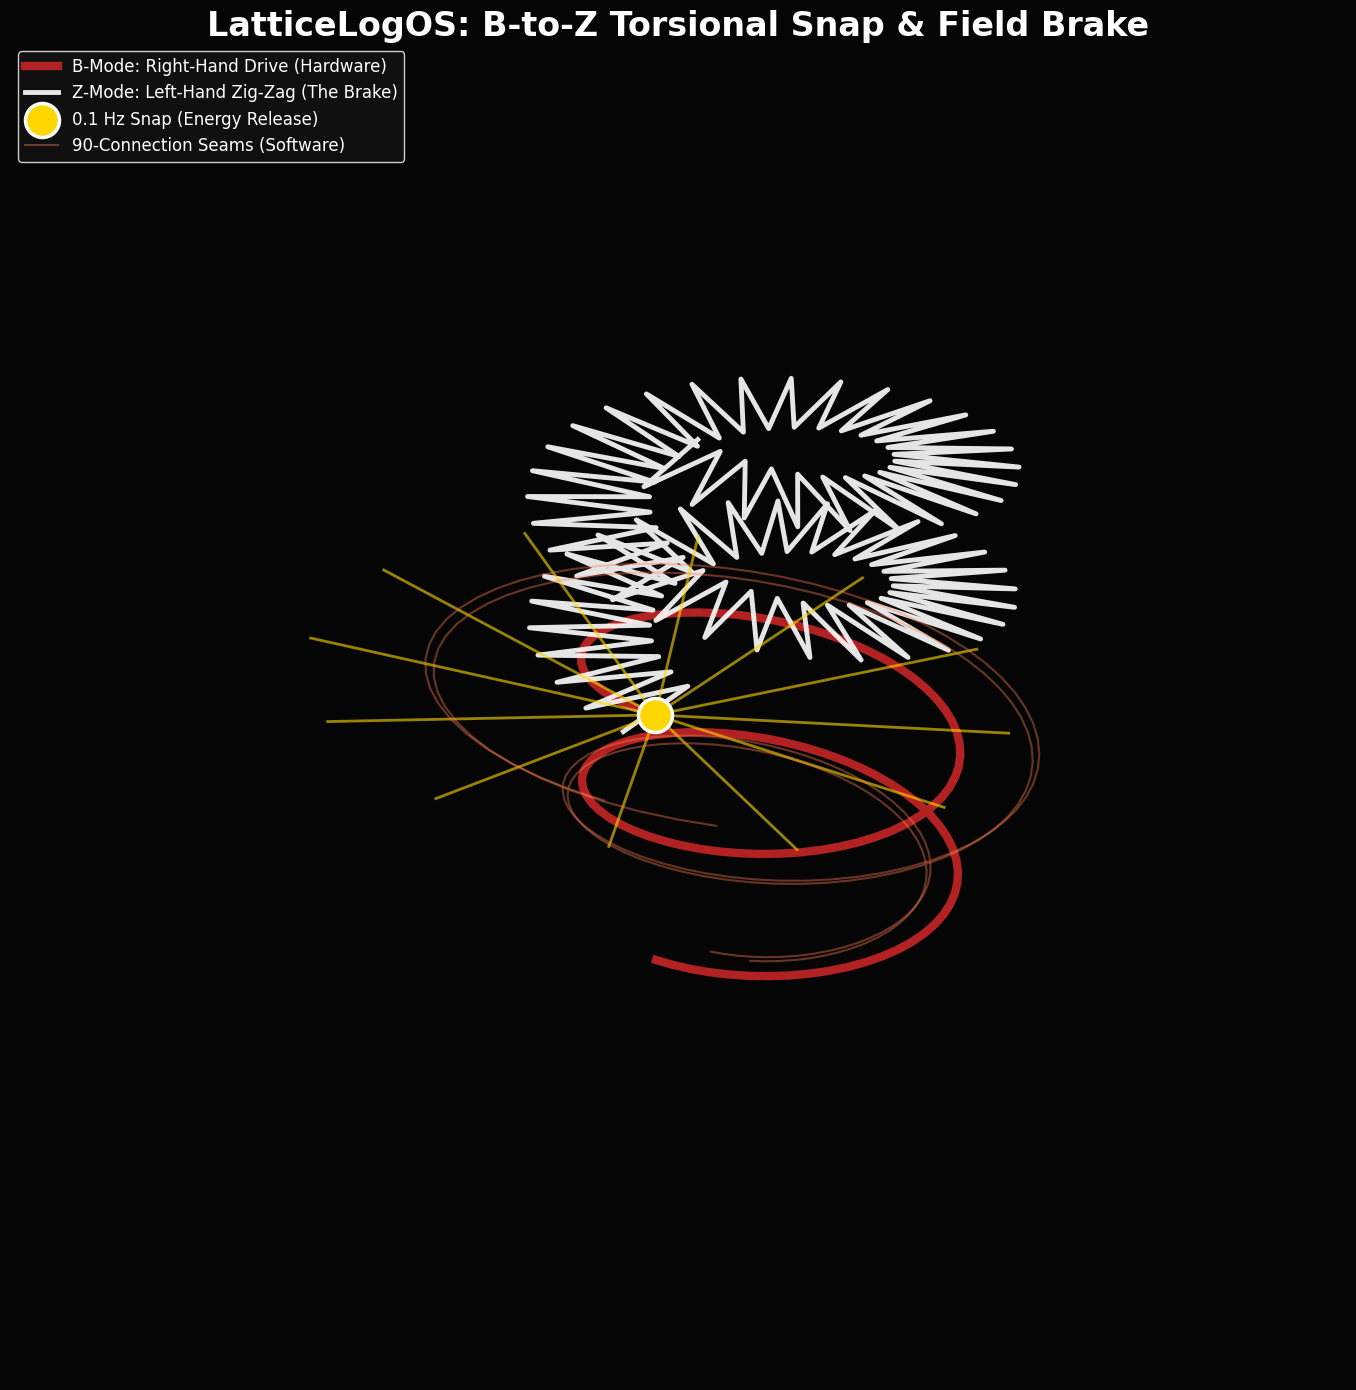

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def generate_latticelogos_snap_rendering():
    fig = plt.figure(figsize=(14, 14), facecolor='#050505')
    ax = fig.add_subplot(111, projection='3d', facecolor='#050505')

    # Parameters for B-DNA (Right-hand) and Z-DNA (Left-hand Zig-Zag)
    t_b = np.linspace(0, 4 * np.pi, 120)
    t_z = np.linspace(4 * np.pi, 8 * np.pi, 120)

    # 1. B-MODE: RIGHT-HAND DRIVE (Hardware)
    r_b = 1.1
    x_b, y_b, z_b = r_b * np.cos(t_b), r_b * np.sin(t_b), t_b * 1.0
    ax.plot(x_b, y_b, z_b, color='firebrick', lw=6, alpha=1.0,
            label='B-Mode: Right-Hand Drive (Hardware)')

    # 2. Z-MODE: LEFT-HAND ZIG-ZAG (The Brake)
    # Zig-zag factor: alternating radius to show the 'crease' logic
    zig = np.tile([1.4, 0.7], 60)
    x_z, y_z, z_z = zig * np.cos(-t_z), zig * np.sin(-t_z), t_z * 1.0
    ax.plot(x_z, y_z, z_z, color='white', lw=3.5, alpha=0.9,
            label='Z-Mode: Left-Hand Zig-Zag (The Brake)')

    # 3. THE 0.1 Hz SNAP POINT (Biophotonic Burst)
    snap_x, snap_y, snap_z = x_b[-1], y_b[-1], z_b[-1]
    ax.scatter(snap_x, snap_y, snap_z, color='gold', s=600, edgecolors='white',
               linewidth=2.5, alpha=1, label='0.1 Hz Snap (Energy Release)')

    # 4. EMF RADIATION (Clock Rays)
    for i in range(12):
        angle = i * (2 * np.pi / 12)
        ax.plot([snap_x, snap_x + 2.0 * np.cos(angle)],
                [snap_y, snap_y + 2.0 * np.sin(angle)],
                [snap_z, snap_z + 1.5], color='gold', lw=2.0, alpha=0.6)

    # 5. SECONDARY TENSION FIELDS (Software Seams)
    # Using coral paths to represent the underlying 90-connection matrix
    for offset in [0.2, 0.5]:
        r_s = 0.8 * np.exp(0.08 * t_b)
        ax.plot(r_s * np.cos(t_b + offset), r_s * np.sin(t_b + offset), z_b,
                color='coral', lw=1.5, alpha=0.4, label='90-Connection Seams (Software)')

    # View and Aesthetic Legending
    ax.view_init(elev=28, azim=42)
    ax.set_axis_off()

    # Filter legend for unique labels
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    leg = ax.legend(by_label.values(), by_label.keys(), loc='upper left',
                    frameon=True, fontsize=12, facecolor='#141414',
                    edgecolor='white', labelcolor='white')

    plt.title("LatticeLogOS: B-to-Z Torsional Snap & Field Brake",
              color='white', fontsize=24, fontweight='bold', pad=-30)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    generate_latticelogos_snap_rendering()

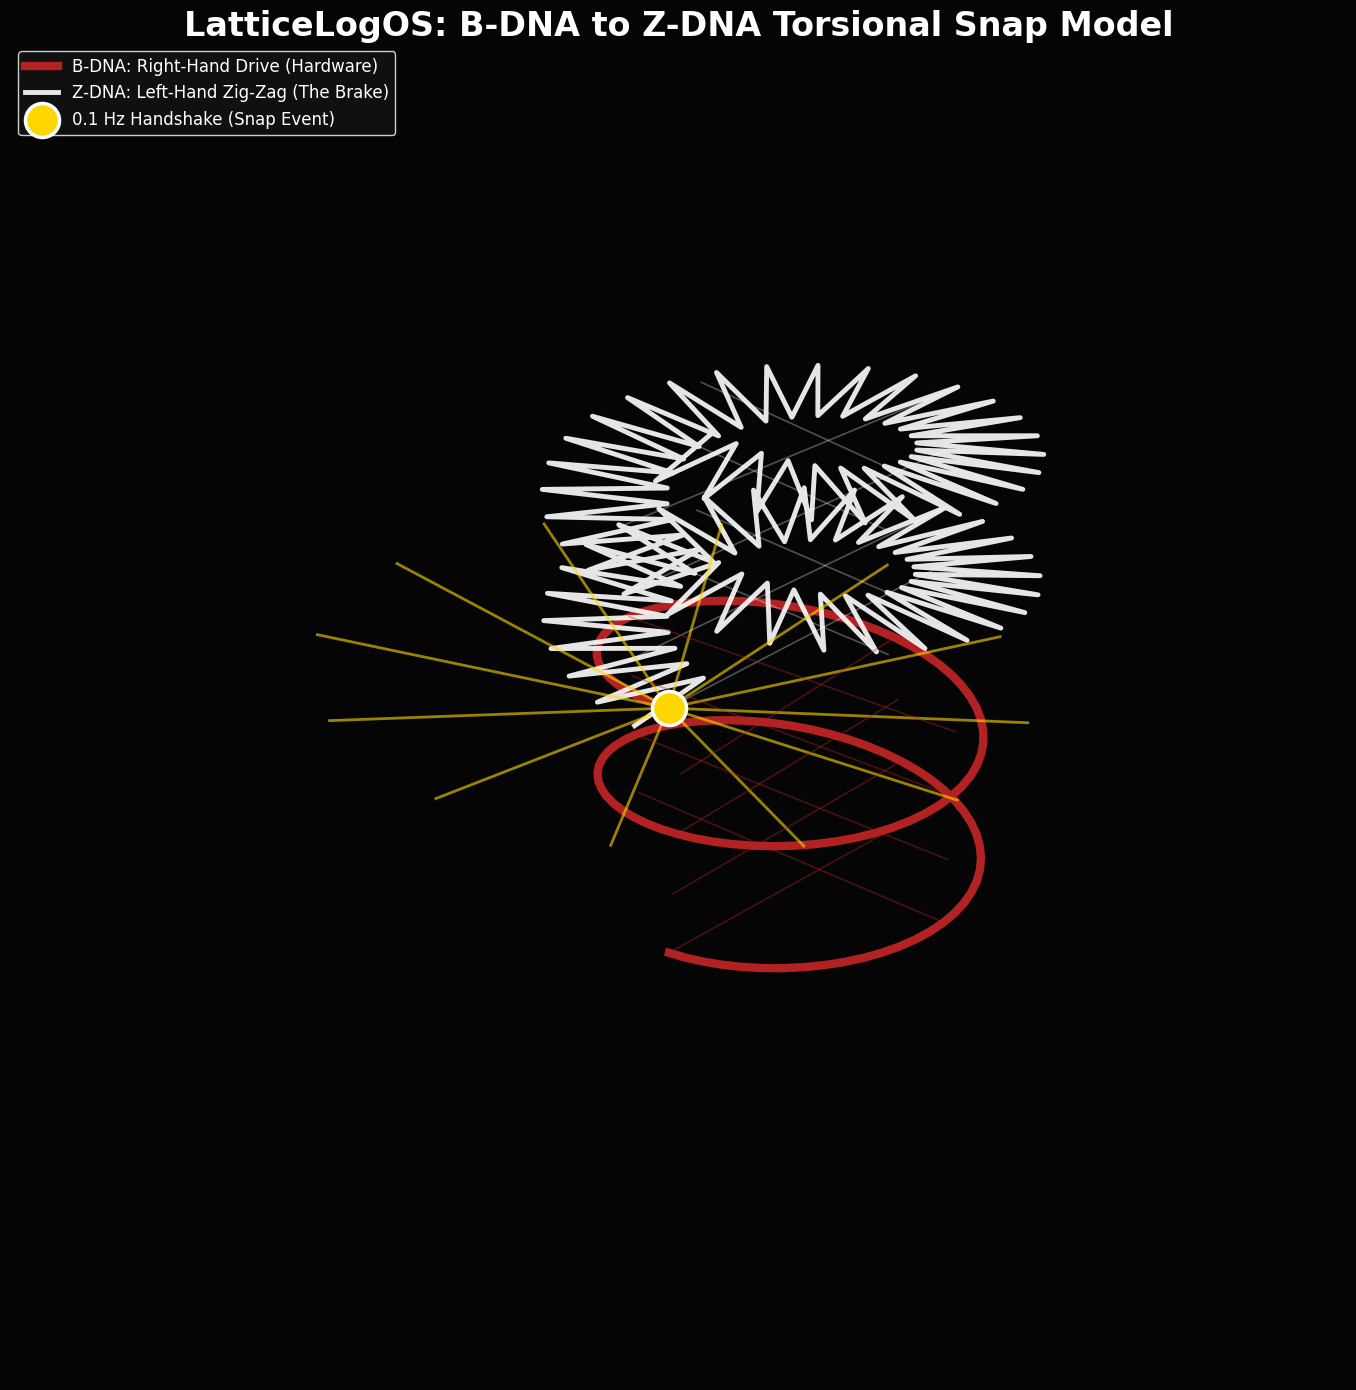

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def generate_latticelogos_dna_chart():
    fig = plt.figure(figsize=(14, 14), facecolor='#050505')
    ax = fig.add_subplot(111, projection='3d', facecolor='#050505')

    # Parameters for B-DNA (Right-hand) and Z-DNA (Left-hand Zig-Zag)
    t_b = np.linspace(0, 4 * np.pi, 120)
    t_z = np.linspace(4 * np.pi, 8 * np.pi, 120)

    # 1. B-DNA MODE: RIGHT-HAND DRIVE (Hardware)
    r_b = 1.1
    x_b, y_b, z_b = r_b * np.cos(t_b), r_b * np.sin(t_b), t_b * 1.0
    ax.plot(x_b, y_b, z_b, color='firebrick', lw=6, alpha=1.0,
            label='B-DNA: Right-Hand Drive (Hardware)')

    # 2. Z-DNA MODE: LEFT-HAND ZIG-ZAG (The Brake)
    # Zig-zag factor: alternating radius to show the 'crease' logic
    zig = np.tile([1.4, 0.7], 60)
    x_z, y_z, z_z = zig * np.cos(-t_z), zig * np.sin(-t_z), t_z * 1.0
    ax.plot(x_z, y_z, z_z, color='white', lw=3.5, alpha=0.9,
            label='Z-DNA: Left-Hand Zig-Zag (The Brake)')

    # 3. THE 0.1 Hz SNAP POINT (Biophotonic Burst)
    snap_x, snap_y, snap_z = x_b[-1], y_b[-1], z_b[-1]
    ax.scatter(snap_x, snap_y, snap_z, color='gold', s=600, edgecolors='white',
               linewidth=2.5, alpha=1, label='0.1 Hz Handshake (Snap Event)')

    # 4. EMF RADIATION (Clock Rays)
    for i in range(12):
        angle = i * (2 * np.pi / 12)
        ax.plot([snap_x, snap_x + 2.0 * np.cos(angle)],
                [snap_y, snap_y + 2.0 * np.sin(angle)],
                [snap_z, snap_z + 1.5], color='gold', lw=2.0, alpha=0.6)

    # 5. DNA BASE PAIR BRIDGES (Hardware Anchors)
    # These rungs identify the structure as DNA
    for i in range(0, 120, 15):
        # B-DNA Rungs
        ax.plot([x_b[i], -x_b[i]], [y_b[i], -y_b[i]], [z_b[i], z_b[i]],
                color='firebrick', lw=1.2, alpha=0.4)
        # Z-DNA Rungs
        ax.plot([x_z[i], -x_z[i]], [y_z[i], -y_z[i]], [z_z[i], z_z[i]],
                color='white', lw=1.2, alpha=0.3)

    # View and Aesthetic Legending
    ax.view_init(elev=28, azim=42)
    ax.set_axis_off()

    # Filter legend for unique labels
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    leg = ax.legend(by_label.values(), by_label.keys(), loc='upper left',
                    frameon=True, fontsize=12, facecolor='#141414',
                    edgecolor='white', labelcolor='white')

    plt.title("LatticeLogOS: B-DNA to Z-DNA Torsional Snap Model",
              color='white', fontsize=24, fontweight='bold', pad=-30)

    plt.tight_layout()
    plt.show()

generate_latticelogos_dna_chart()

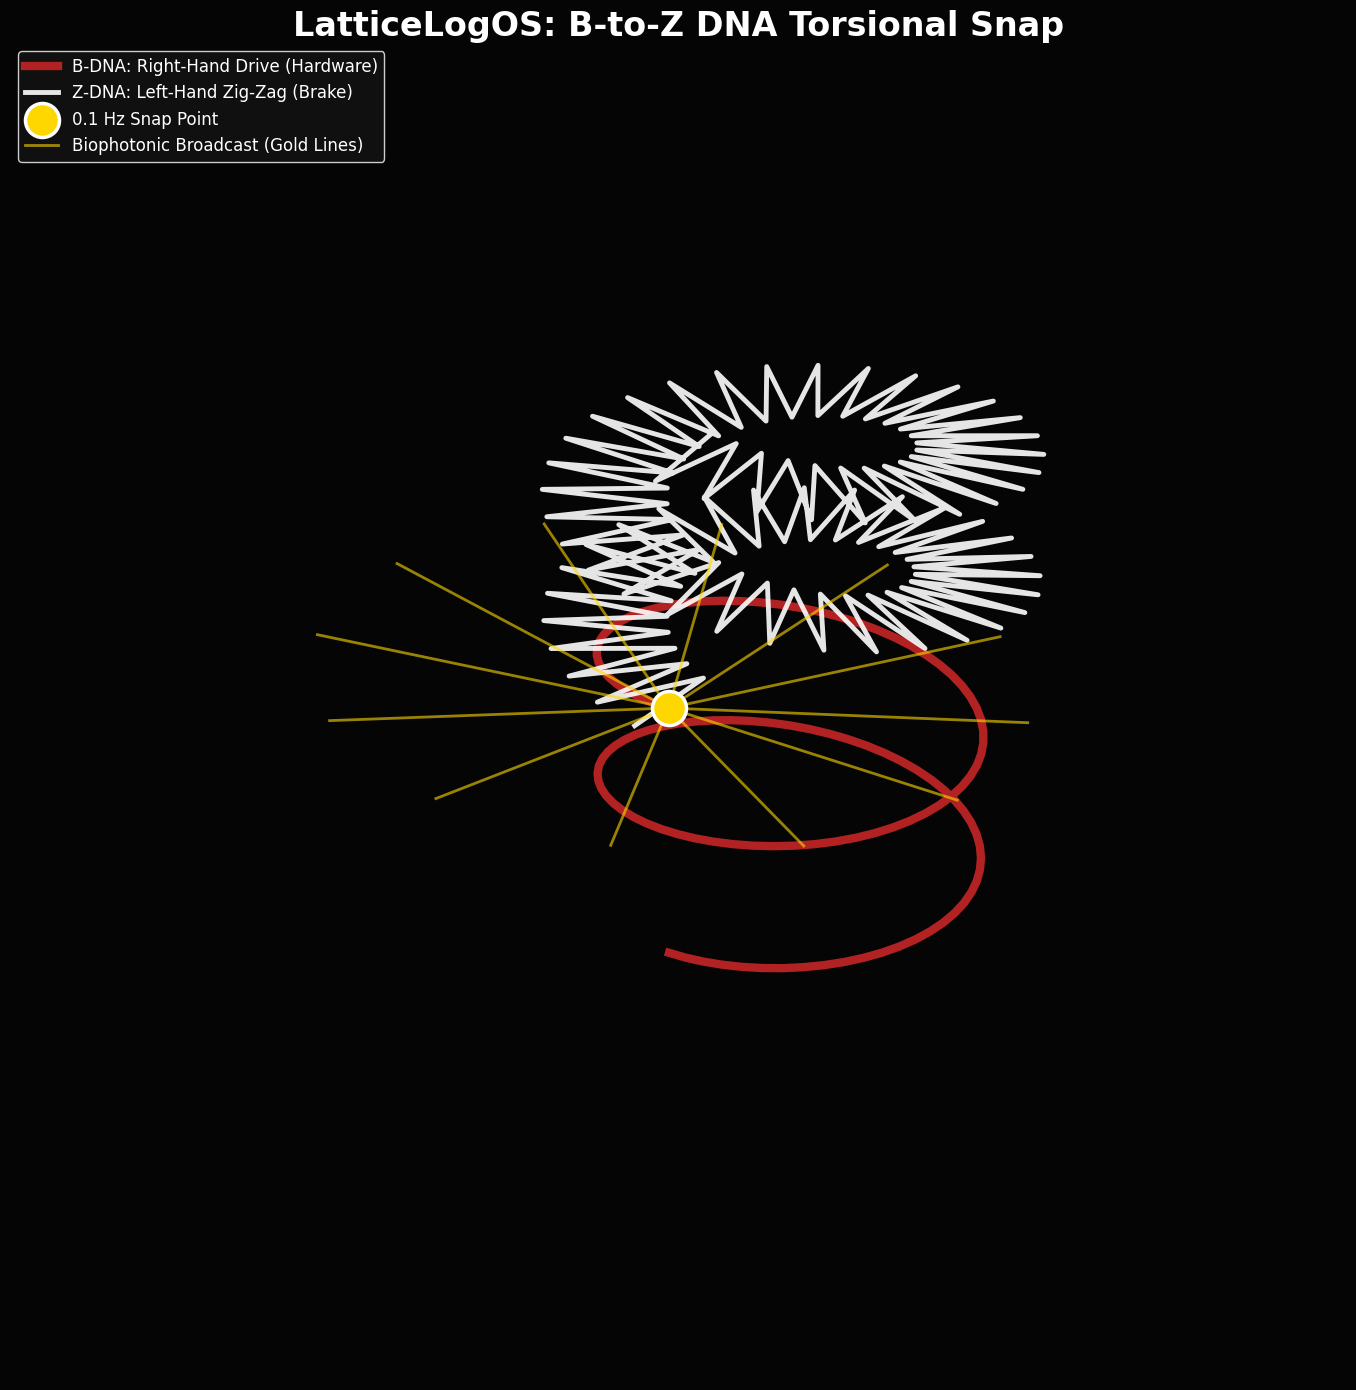

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def generate_latticelogos_dna_final():
    fig = plt.figure(figsize=(14, 14), facecolor='#050505')
    ax = fig.add_subplot(111, projection='3d', facecolor='#050505')

    t_b = np.linspace(0, 4 * np.pi, 120)
    t_z = np.linspace(4 * np.pi, 8 * np.pi, 120)

    # 1. B-DNA (Hardware)
    r_b = 1.1
    x_b, y_b, z_b = r_b * np.cos(t_b), r_b * np.sin(t_b), t_b * 1.0
    ax.plot(x_b, y_b, z_b, color='firebrick', lw=6, alpha=1.0, label='B-DNA: Right-Hand Drive (Hardware)')

    # 2. Z-DNA (The Brake)
    zig = np.tile([1.4, 0.7], 60)
    x_z, y_z, z_z = zig * np.cos(-t_z), zig * np.sin(-t_z), t_z * 1.0
    ax.plot(x_z, y_z, z_z, color='white', lw=3.5, alpha=0.9, label='Z-DNA: Left-Hand Zig-Zag (Brake)')

    # 3. 0.1 Hz Snap Point
    snap_x, snap_y, snap_z = x_b[-1], y_b[-1], z_b[-1]
    ax.scatter(snap_x, snap_y, snap_z, color='gold', s=600, edgecolors='white', linewidth=2.5, alpha=1, label='0.1 Hz Snap Point')

    # 4. Biophotonic Broadcast (Gold Lines)
    first_ray = True
    for i in range(12):
        angle = i * (2 * np.pi / 12)
        ax.plot([snap_x, snap_x + 2.0 * np.cos(angle)], [snap_y, snap_y + 2.0 * np.sin(angle)], [snap_z, snap_z + 1.5],
                color='gold', lw=2.0, alpha=0.6, label='Biophotonic Broadcast (Gold Lines)' if first_ray else "")
        first_ray = False

    # Formatting
    ax.view_init(elev=28, azim=42)
    ax.set_axis_off()
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    leg = ax.legend(by_label.values(), by_label.keys(), loc='upper left', frameon=True, fontsize=12, facecolor='#141414', edgecolor='white', labelcolor='white')

    plt.title("LatticeLogOS: B-to-Z DNA Torsional Snap", color='white', fontsize=24, fontweight='bold', pad=-30)
    plt.tight_layout()
    plt.show()

generate_latticelogos_dna_final()